# GA-BO-TR — Part 3: Strong Baselines, BBOB-24, Engineering, Statistics

This notebook runs the full experimental campaign for the paper.

**Reading order for the headline.**
1. §3 Engineering with **constrained-EI** (Gardner 2014, now properly
   wired to BoTorch's multi-output `ModelListGP`).  This is one of the
   two main contributions: GA-BO-TR + cEI on Welded Beam, Pressure
   Vessel, Tension Spring, Speed Reducer, compared against the naive
   quadratic-penalty approach as a sanity check.
2. §4 BBOB-24 sweep + §6 summary tables — the wrapper's general-
   purpose performance vs. TuRBO-1, HEBO, CMA-ES, Optuna-TPE.
3. §5 Statistical protocol — Friedman + Iman-Davenport + Holm
   (one-vs-control) + Nemenyi all-pairs + critical-difference diagram,
   via `scikit-posthocs`.

**Sections in execution order.**

1. **Strong baselines** — HEBO (JAIR 2022, configured with `model_name="gp"`),
   TuRBO-1 (NeurIPS 2019), CMA-ES (Hansen), Optuna-TPE, Random.
2. **Main synthetic comparison** — 9 functions × 8 methods × 15 seeds.
3. **Engineering design** with proper constrained BO — see §3 above.
4. **BBOB-24 sweep** — toggle `DRY_RUN` (cell below); full sweep is
   24 × 3 × 3 × 15 ≈ 75 hours on a laptop.
5. **Statistical protocol** — see above.
6. **Summary tables** and the LaTeX export for the paper.
7. **BBOB-24 ECDF** figure (when full sweep is available).
8. **Final summary**.

> **Known gaps (future work).**  We do not include SAASBO (Eriksson &
> Jankowiak 2021) or BAxUS (Papenmeier et al. 2022) as baselines.  Both
> are state of the art for $d \ge 20$; not having them limits any claim
> about high-dimensional performance.  We restrict the headline claim
> to $d \le 20$ where TuRBO-1 / HEBO / CMA-ES are competitive baselines.

Run Parts 1 and 2 first (in the same kernel).


Environment ready.
Config done — dtype = double, device = cuda
Registered 10 synthetic functions.
BBOB smoke: BBOB-f01-i1-d5 f(0)=92.304, f*=79.480
GP smoke-test  mu[:5] = [42.783 45.717 54.14  42.713 22.983]
             sigma[:5] = [0.024 0.02  0.023 0.026 0.026]


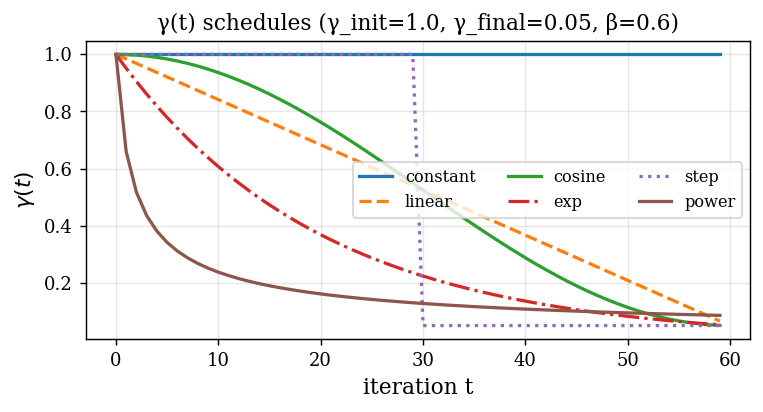

ELA smoke: 37 raw features, summary =
   skewness     = -1.0553
   kurtosis     = +1.2561
   n_peaks      = +2.0000
   h_max        = +0.8975
   eps_s        = +0.0851
   m0           = +0.6379
   nb_fit_cor   = -0.7165
   nn_mean      = +0.8898
   disp_25      = +0.7423
   disp_05      = +0.4525
   pca_expl_x   = +1.0000
GA / DE optimisers defined.
Base BO loops defined: StandardBO, GA_BO, RandomSearch.
StandardBO       final regret =   2.9471   wall =  11.9s
GA-BO(DIV)       final regret =   6.4660   wall =   4.0s
Random           final regret =   5.9122   wall =   0.0s
Part 1 ready.


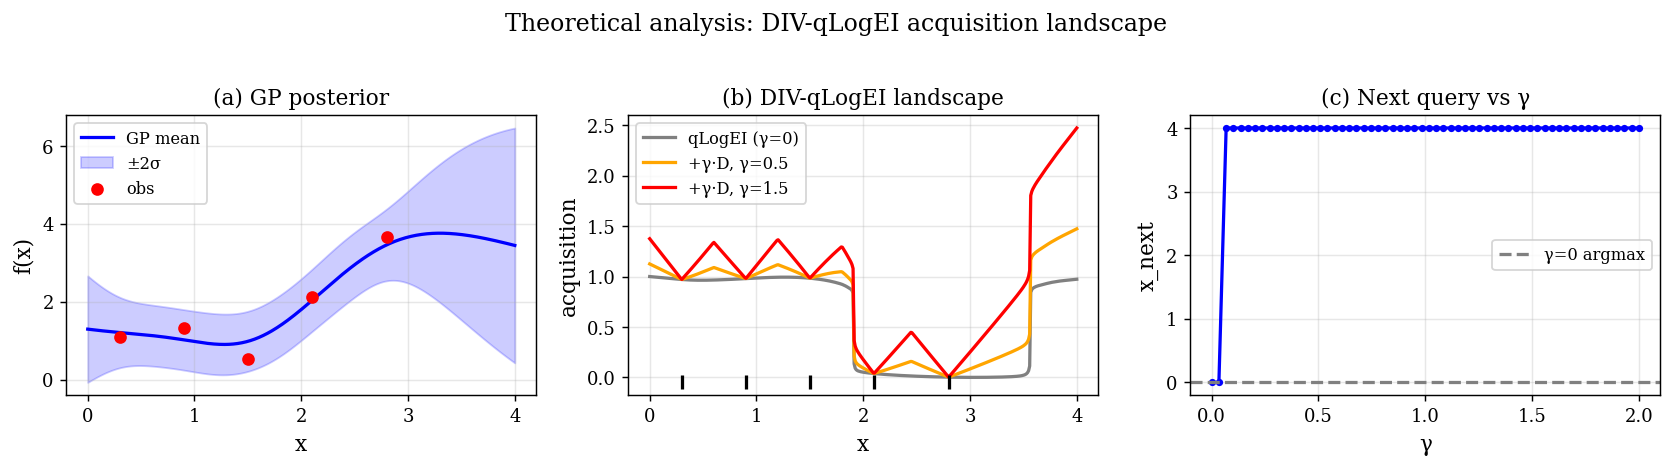

GA_BO_TR defined - the main proposed method.
Loaded cached classifier from results_gabotr/ela_gamma_rf.joblib
Total tasks: 200  (5 methods × 4 functions × 10 seeds)


Running:   0%|          | 0/200 [00:00<?, ?it/s]

Saved → results_gabotr/ablation.json


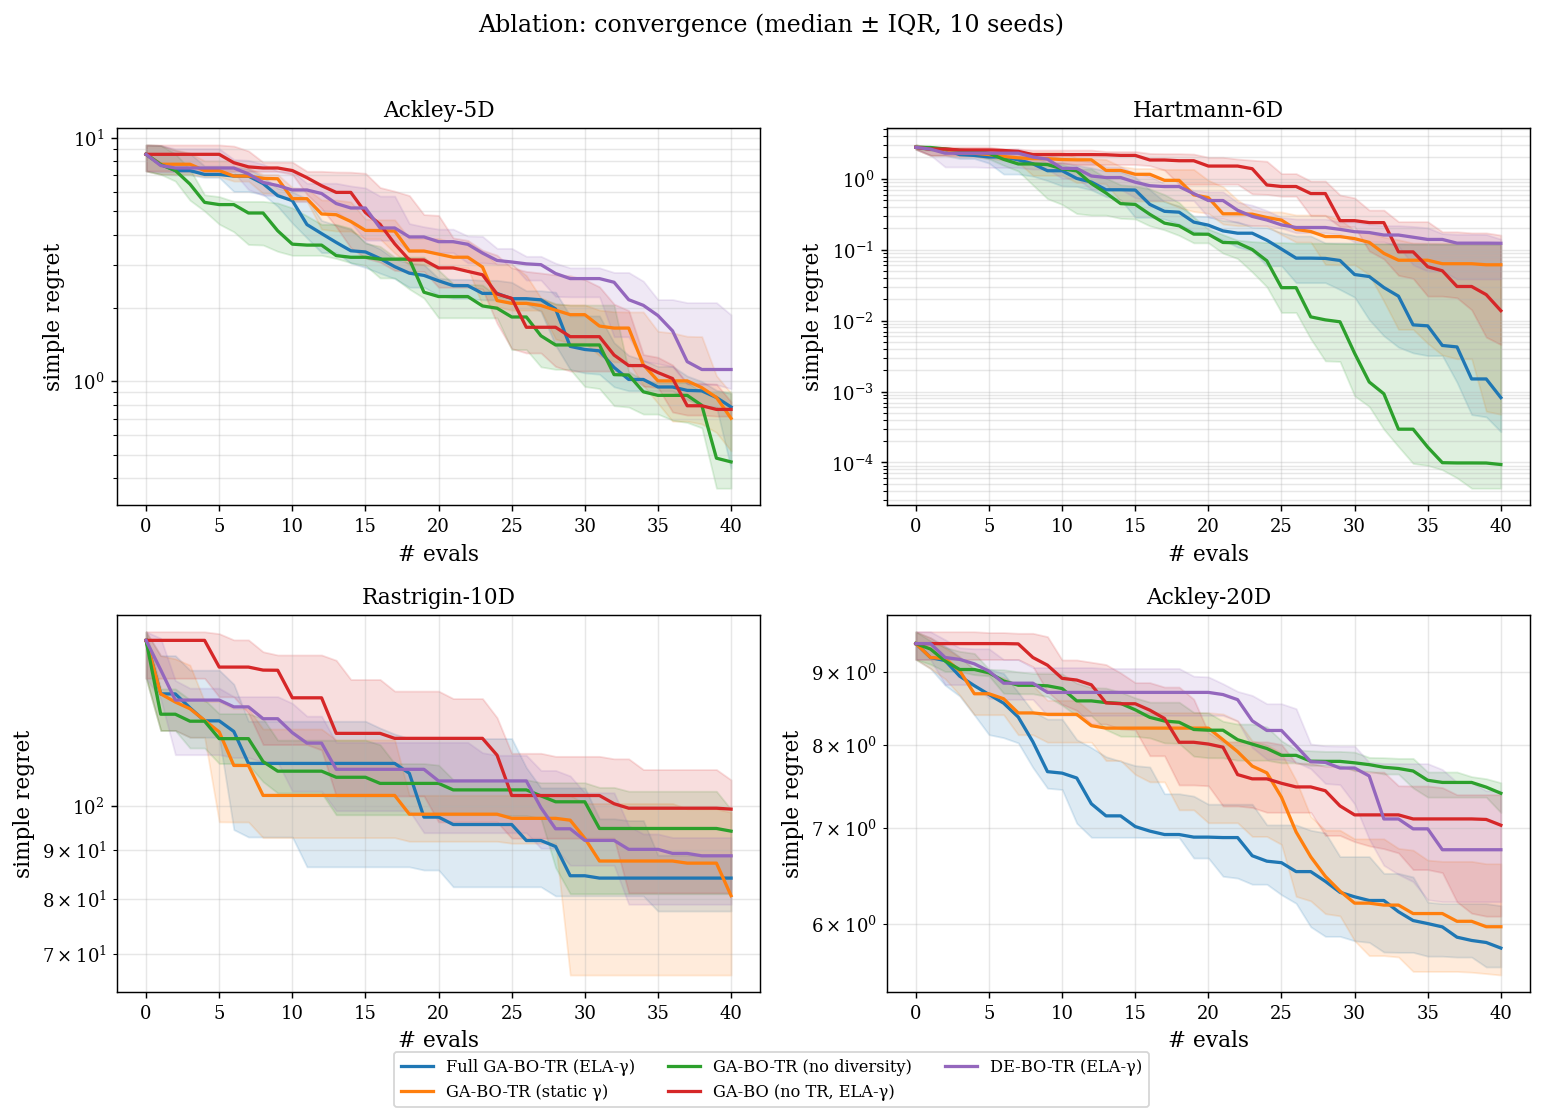

Saved figures_gabotr/ablation_convergence.pdf


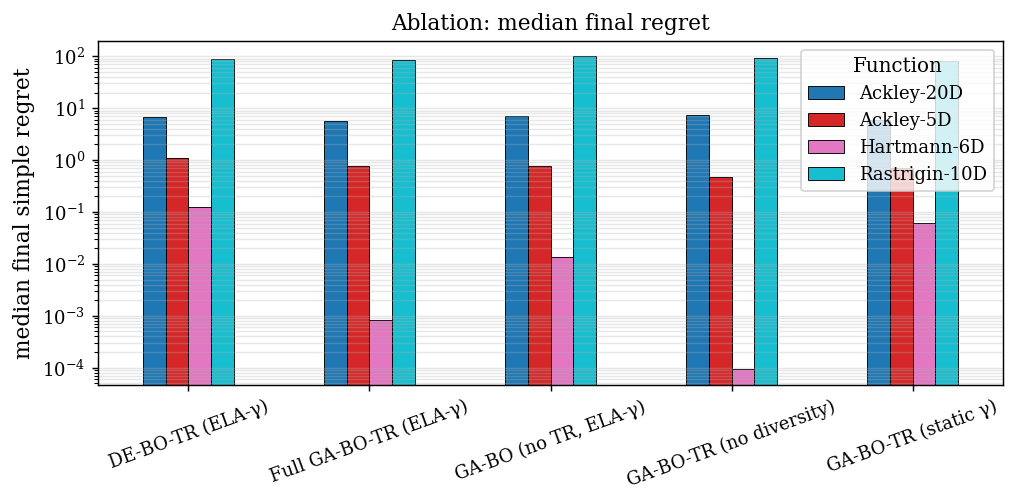

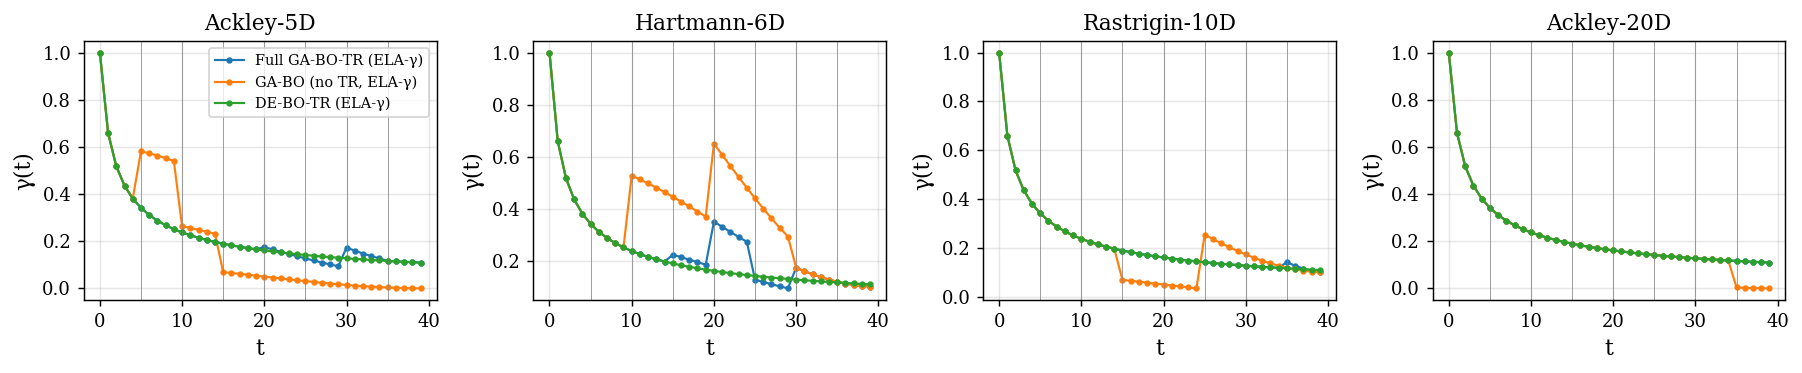

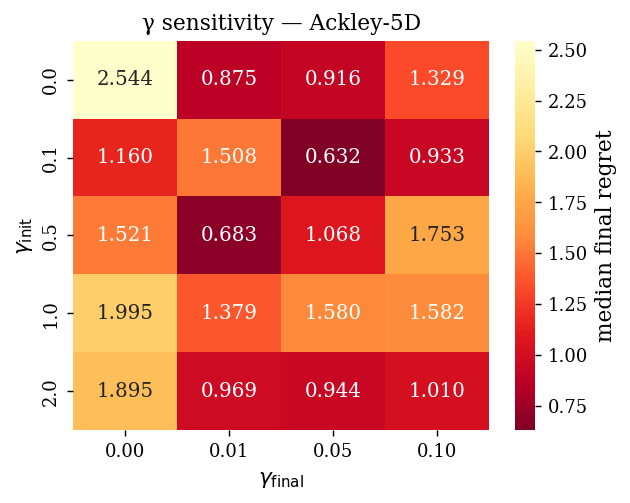

In [2]:
%run GA_BO_TR_Part2.ipynb


## 1. Strong baselines


In [3]:
class CMAESBaseline:
    """CMA-ES (Hansen) wrapped to share the BOResult signature."""

    def __init__(self, bounds, n_init: int = 5, n_iter: int = 50,
                 seed: int = 42,
                 sigma0_unit: float = 0.2,
                 popsize: "Optional[int]" = None,
                 restarts: int = 3,
                 lhs_warm_start: bool = True,
                 **_):
        self.bounds = bounds
        self.d = bounds.shape[0]
        self.n_init = n_init
        self.n_iter = n_iter
        self.n_total = n_init + n_iter
        self.seed = seed
        self.sigma0_unit = sigma0_unit
        self.popsize = popsize
        self.restarts = restarts
        self.lhs_warm_start = lhs_warm_start
        self.rng = np.random.RandomState(seed)

    # ------------------------------------------------------------------ run
    def run(self, objective, func_name="unknown", verbose=False) -> "BOResult":
        import cma

        t0 = time.time()
        lo, hi = self.bounds[:, 0], self.bounds[:, 1]
        span = hi - lo
        span = np.where(span > 0, span, 1.0)          # guard degenerate dims

        Xh, yh = [], []

        def _eval_raw(x_raw):
            x_raw = np.asarray(x_raw, dtype=float)
            val = float(objective(x_raw))
            Xh.append(x_raw)
            yh.append(val)
            return val

        # ---- optional LHS warm start, matching the BO baselines' n_init ----
        if self.lhs_warm_start and self.n_init > 0:
            X0 = lhs_sample(self.n_init, self.bounds, self.rng)
            y0 = [_eval_raw(r) for r in X0]
            z_start = (X0[int(np.argmin(y0))] - lo) / span
            budget_cma = self.n_iter
        else:
            z_start = np.full(self.d, 0.5)
            budget_cma = self.n_total
        z_start = np.clip(z_start, 1e-6, 1.0 - 1e-6)

        # ---- CMA-ES in the unit cube -----------------------------------
        opts = cma.CMAOptions()
        opts["bounds"] = [[0.0] * self.d, [1.0] * self.d]
        opts["maxfevals"] = budget_cma           # total across restarts
        opts["verbose"] = -9
        opts["verb_disp"] = 0
        opts["verb_log"] = 0
        opts["seed"] = int(self.seed) + 1
        if self.popsize is not None:
            opts["popsize"] = int(self.popsize)

        n_fail = 0

        def wrap_unit(z):
            z = np.clip(np.asarray(z, dtype=float), 0.0, 1.0)
            return _eval_raw(lo + z * span)

        try:
            # restarts = standard fixed-budget protocol (IPOP-style).
            # incpopsize=1 keeps popsize constant: at 20*d budgets the
            # population-doubling of textbook IPOP is counterproductive.
            cma.fmin(wrap_unit, z_start.tolist(), self.sigma0_unit,
                     options=opts, restarts=self.restarts, incpopsize=1,
                     bipop=False)
        except Exception as e:
            n_fail += 1
            if verbose:
                print(f"[CMA-ES {func_name} s{self.seed}] terminated early: "
                      f"{type(e).__name__}: {e}")

        if verbose:
            print(f"[CMA-ES {func_name} s{self.seed}] used {len(yh)}/"
                  f"{self.n_total} evaluations")

        # ---- assemble BOResult -----------------------------------------
        yh_arr = np.asarray(yh[:self.n_total], dtype=float)
        Xh_arr = np.asarray(Xh[:self.n_total], dtype=float)

        if yh_arr.size == 0:                     # pathological: never ran
            x_mid = (lo + hi) / 2.0
            yh_arr = np.array([float(objective(x_mid))], dtype=float)
            Xh_arr = np.array([x_mid], dtype=float)
            n_fail += 1

        # BO convention: entry 0 = best after n_init evaluations, then one
        # entry per subsequent evaluation  ->  n_iter + 1 entries.
        k0 = max(1, min(self.n_init, len(yh_arr)))
        best = [float(yh_arr[:k0].min())]
        for i in range(k0, len(yh_arr)):
            best.append(float(yh_arr[:i + 1].min()))

        target_len = self.n_iter + 1
        if len(best) < target_len:
            best += [best[-1]] * (target_len - len(best))
        best = best[:target_len]

        return BOResult(method="CMA-ES", func_name=func_name,
                        best_values=best, x_history=Xh_arr, y_history=yh_arr,
                        wall_time=time.time() - t0, seed=self.seed)


class OptunaTPEBaseline:
    """Tree-structured Parzen Estimator (Bergstra 2011) via Optuna."""
    def __init__(self, bounds, n_init: int = 5, n_iter: int = 50, seed: int = 42, **_):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.n_init = n_init; self.n_iter = n_iter
        self.seed = seed; self.n_total = n_init + n_iter

    def run(self, objective, func_name="unknown", verbose=False) -> BOResult:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        t0 = time.time()
        lo, hi = self.bounds[:,0], self.bounds[:,1]
        Xh, yh = [], []
        def obj(trial):
            x = np.array([trial.suggest_float(f"x{j}", float(lo[j]), float(hi[j]))
                          for j in range(self.d)])
            val = float(objective(x))
            Xh.append(x); yh.append(val); return val
        sampler = optuna.samplers.TPESampler(seed=self.seed)
        study = optuna.create_study(direction="minimize", sampler=sampler)
        study.optimize(obj, n_trials=self.n_total, show_progress_bar=False)
        Xh = np.array(Xh); yh = np.array(yh)
        best = [float(np.min(yh[:i+1])) for i in range(len(yh))]
        return BOResult(method="Optuna-TPE", func_name=func_name,
                        best_values=best, x_history=Xh, y_history=yh,
                        wall_time=time.time()-t0, seed=self.seed)


In [4]:
class TuRBO1Baseline:
    """TuRBO-1 baseline: TuRBO state machine + Thompson sampling inside TR."""
    def __init__(self, bounds, n_init: int = 10, n_iter: int = 50,
                 kernel: str = "matern52", seed: int = 42, **_):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.n_init = n_init; self.n_iter = n_iter
        self.kernel = kernel; self.seed = seed
        self.rng = np.random.RandomState(seed)

    def _ts_inside_tr(self, gp, y_obs_np, tr_bounds, n_cand: int) -> np.ndarray:
        """Thompson sampling: sample function values at random TR candidates, pick argmin."""
        lo, hi = tr_bounds[:,0], tr_bounds[:,1]
        X_cand = lo + self.rng.rand(n_cand, self.d) * (hi - lo)
        Xt = torch.as_tensor(X_cand, dtype=DTYPE, device=DEVICE)
        with torch.no_grad():
            post = gp.posterior(Xt)
            samples = post.rsample(torch.Size([1])).squeeze(0)  # (n_cand, 1)
        samples = samples.detach().cpu().numpy().ravel()
        if getattr(gp, "_maximize_flag", False):
            # Internal max → want argmax = min in raw scale
            return X_cand[int(np.argmax(samples))]
        else:
            return X_cand[int(np.argmin(-samples))]   # posterior is on -y internally

    def run(self, objective, func_name="unknown", verbose=False) -> BOResult:
        torch.manual_seed(int(self.seed))   # reproducibility for posterior.rsample
        t0 = time.time()
        X_obs = lhs_sample(self.n_init, self.bounds, self.rng)
        y_obs = np.array([objective(r) for r in X_obs])
        best = [float(y_obs.min())]
        tr_hist: List[float] = []

        state = TurboState(dim=self.d, batch_size=1, length=0.8, success_tolerance=10)
        state.best_value = float(y_obs.min())

        for _ in range(self.n_iter):
            gp = build_gp(X_obs, y_obs, self.bounds, kernel=self.kernel)
            y_best_prev = float(y_obs.min())
            x_center = X_obs[int(np.argmin(y_obs))]
            tr_b = trust_region_bounds(gp, x_center, self.bounds, state.length)
            tr_hist.append(float(state.length))
            x_next = self._ts_inside_tr(gp, y_obs, tr_b, n_cand=min(2000, 200*self.d))
            y_next = float(objective(x_next))
            X_obs = np.vstack([X_obs, x_next]); y_obs = np.append(y_obs, y_next)
            best.append(float(y_obs.min()))
            state = update_turbo_state(state, y_next, y_best_prev)
            if state.restart_triggered:
                state = TurboState(dim=self.d, batch_size=1, length=0.8, success_tolerance=10)
                state.best_value = float(y_obs.min())

        return BOResult(method="TuRBO-1", func_name=func_name,
                        best_values=best, x_history=X_obs, y_history=y_obs,
                        tr_length_hist=tr_hist, wall_time=time.time()-t0, seed=self.seed)


In [5]:
class HEBOBaseline:
    """
    HEBO (Cowen-Rivers et al., JAIR 2022) - input warping + BO.  Safe wrapper
    that reports a RandomSearch fallback if hebo is not installed.
    """
    def __init__(self, bounds, n_init: int = 5, n_iter: int = 50, seed: int = 42, **_):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.n_init = n_init; self.n_iter = n_iter
        self.seed = seed

    def run(self, objective, func_name="unknown", verbose=False) -> BOResult:
        try:
            from hebo.design_space.design_space import DesignSpace
            from hebo.optimizers.hebo import HEBO
            import pandas as pd
        except Exception as e:
            if verbose: print(f"HEBO unavailable ({e}); falling back to RandomSearch.")
            return RandomSearch(self.bounds, self.n_init, self.n_iter,
                                seed=self.seed).run(objective, func_name=func_name)
        t0 = time.time()
        np.random.seed(self.seed)
        lo, hi = self.bounds[:,0], self.bounds[:,1]
        space = DesignSpace().parse([
            {"name": f"x{i}", "type": "num", "lb": float(lo[i]), "ub": float(hi[i])}
            for i in range(self.d)
        ])
        # model_name="gp" uses HEBO's internal torch GP (no optional GPy
        # backend required).  The previous "gpy" silently fell back to random
        # whenever GPy was missing, which biased earlier comparisons.
        try:
            opt = HEBO(space, model_name="gp", rand_sample=self.n_init)
        except TypeError:
            opt = HEBO(space, model_name="gp")
        total = self.n_init + self.n_iter
        Xh, yh = [], []
        n_fail = 0
        for i in range(total):
            try:
                rec = opt.suggest(n_suggestions=1)
                x = rec.iloc[0].values.astype(float)
                val = float(objective(x))
                opt.observe(rec, np.array([[val]]))
                Xh.append(x); yh.append(val)
            except Exception as e:
                n_fail += 1
                if verbose and n_fail <= 3:
                    print(f"[HEBO {func_name} s{self.seed} iter {i}] {type(e).__name__}: {e}")
                x = lo + np.random.rand(self.d)*(hi-lo)
                val = float(objective(x))
                Xh.append(x); yh.append(val)
        if n_fail > 0:
            print(f"[HEBO {func_name} s{self.seed}] {n_fail}/{total} iterations fell back to random.")
        Xh = np.array(Xh); yh = np.array(yh)
        best = [float(np.min(yh[:i+1])) for i in range(len(yh))]
        return BOResult(method="HEBO", func_name=func_name,
                        best_values=best, x_history=Xh, y_history=yh,
                        wall_time=time.time()-t0, seed=self.seed)


print("Baselines registered: CMA-ES, Optuna-TPE, TuRBO-1, HEBO.")


# ============================================================================
# divTuRBO — Perera, Neumann & Neumann (2025) baseline (arXiv:2511.00750)
# ============================================================================
class DivTuRBOBaseline:
    """divTuRBO1 — TuRBO-1 with a diversity-distance constraint on candidates.

    Mechanism: at each TR-restricted Thompson-sampling step, reject Sobol
    candidates that lie within `delta_frac * L_t` (lengthscale-weighted) of any
    point already in the archive.  If too few candidates survive, halve delta
    and retry; this prevents the TR from collapsing on saturated regions.
    """
    def __init__(self, bounds, n_init: int = 10, n_iter: int = 50,
                 delta_frac: float = 0.1, n_candidates: int = 2000,
                 kernel: str = "matern52", seed: int = 42, **_):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.n_init = n_init; self.n_iter = n_iter
        self.delta_frac = delta_frac
        self.n_candidates = n_candidates
        self.kernel = kernel; self.seed = seed
        self.rng = np.random.RandomState(seed)

    def _filtered_ts(self, gp, X_obs, tr_b, length):
        lo, hi = tr_b[:, 0], tr_b[:, 1]
        n_cand = min(self.n_candidates, 200 * self.d)
        X_cand = lo + self.rng.rand(n_cand, self.d) * (hi - lo)

        # Lengthscale-weighted min-distance to archive
        try:
            ell = gp.covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()
        except AttributeError:
            ell = gp.covar_module.lengthscale.detach().cpu().numpy().ravel()
        # Clamp lengthscales: tiny ell -> exploding distances -> diversity
        # filter rejects everything; huge ell -> distances vanish -> filter
        # is a no-op.  Bracket within sane physical range.
        ell_safe = np.clip(ell, 1e-3, 1e3)
        Xc_s = X_cand / ell_safe
        Xo_s = X_obs / ell_safe
        dmin = cdist(Xc_s, Xo_s).min(axis=1)

        # Threshold scales with TR length and the (weighted) box diameter
        diag_w = np.linalg.norm((self.bounds[:, 1] - self.bounds[:, 0]) / ell_safe)
        delta = self.delta_frac * length * diag_w
        mask = dmin > delta
        # Relax until enough candidates survive — minimum is the larger of
        # 200 absolute (avoids degenerate sampling at small d) and 10% of
        # the candidate pool (keeps relative diversity at large d).
        relax = 0
        min_survivors = max(200, int(0.1 * n_cand))
        while mask.sum() < min_survivors and relax < 5:
            delta *= 0.5
            mask = dmin > delta
            relax += 1
        if not mask.any():
            mask = np.ones(n_cand, dtype=bool)
        X_filt = X_cand[mask]

        Xt = torch.as_tensor(X_filt, dtype=DTYPE, device=DEVICE)
        with torch.no_grad():
            samples = gp.posterior(Xt).rsample(torch.Size([1])).squeeze(0)
        samples = samples.detach().cpu().numpy().ravel()
        # build_gp internally trains on -Y (max-seeking), so argmax of the
        # posterior sample picks the candidate predicted to minimise the raw
        # objective.  No need for a `_maximize_flag` branch — the convention
        # is fixed by build_gp.
        return X_filt[int(np.argmax(samples))]

    def run(self, objective, func_name="unknown", verbose=False) -> BOResult:
        torch.manual_seed(int(self.seed))   # reproducibility for posterior.rsample
        t0 = time.time()
        X_obs = lhs_sample(self.n_init, self.bounds, self.rng)
        y_obs = np.array([objective(r) for r in X_obs])
        best = [float(y_obs.min())]
        tr_hist: List[float] = []

        state = TurboState(dim=self.d, batch_size=1, length=0.8, success_tolerance=10)
        state.best_value = float(y_obs.min())

        for _ in range(self.n_iter):
            gp = build_gp(X_obs, y_obs, self.bounds, kernel=self.kernel)
            y_best_prev = float(y_obs.min())
            x_center = X_obs[int(np.argmin(y_obs))]
            tr_b = trust_region_bounds(gp, x_center, self.bounds, state.length)
            tr_hist.append(float(state.length))
            x_next = self._filtered_ts(gp, X_obs, tr_b, state.length)
            y_next = float(objective(x_next))
            X_obs = np.vstack([X_obs, x_next]); y_obs = np.append(y_obs, y_next)
            best.append(float(y_obs.min()))
            state = update_turbo_state(state, y_next, y_best_prev)
            if state.restart_triggered:
                state = TurboState(dim=self.d, batch_size=1, length=0.8, success_tolerance=10)
                state.best_value = float(y_obs.min())

        return BOResult(method="divTuRBO", func_name=func_name,
                        best_values=best, x_history=X_obs, y_history=y_obs,
                        tr_length_hist=tr_hist, wall_time=time.time()-t0, seed=self.seed)


# ============================================================================
# SAASBO baseline — Eriksson & Jankowiak (UAI 2021), via BoTorch fully
# Bayesian SaasFullyBayesianSingleTaskGP + NUTS posterior sampling.
# ============================================================================
class SAASBOBaseline:
    """SAASBO — Sparse Axis-Aligned Subspace BO.

    Fully Bayesian GP with sparsity-inducing (half-Cauchy) prior on the
    inverse lengthscales.  Slow: NUTS at every iteration.  Per-iter cost
    ~30-90s for d <= 30; budget accordingly.
    """
    def __init__(self, bounds, n_init: int = 10, n_iter: int = 50,
                 num_samples: int = 256, warmup_steps: int = 256,
                 thinning: int = 16, n_restarts_acq: int = 8,
                 raw_samples: int = 256, seed: int = 42, **_):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.n_init = n_init; self.n_iter = n_iter
        self.num_samples = num_samples
        self.warmup_steps = warmup_steps
        self.thinning = thinning
        self.n_restarts_acq = n_restarts_acq
        self.raw_samples = raw_samples
        self.seed = seed
        self.rng = np.random.RandomState(seed)

    def run(self, objective, func_name="unknown", verbose=False) -> BOResult:
        try:
            from botorch.models.fully_bayesian import SaasFullyBayesianSingleTaskGP
            from botorch.fit import fit_fully_bayesian_model_nuts
            from botorch.acquisition.logei import qLogExpectedImprovement
            from botorch.acquisition.objective import IdentityMCObjective
            from botorch.sampling.normal import SobolQMCNormalSampler
            from botorch.optim import optimize_acqf
            from botorch.models.transforms.input import Normalize
            from botorch.models.transforms.outcome import Standardize
        except Exception as e:
            print(f"[SAASBO {func_name}] BoTorch SAAS unavailable ({e}); fallback to RandomSearch.")
            return RandomSearch(self.bounds, self.n_init, self.n_iter,
                                seed=self.seed).run(objective, func_name=func_name)

        torch.manual_seed(int(self.seed))
        t0 = time.time()
        X_obs = lhs_sample(self.n_init, self.bounds, self.rng)
        y_obs = np.array([objective(r) for r in X_obs])
        best = [float(y_obs.min())]

        bounds_t = torch.as_tensor(self.bounds.T, dtype=DTYPE, device=DEVICE)

        for t in range(self.n_iter):
            Xt = torch.as_tensor(X_obs, dtype=DTYPE, device=DEVICE)
            Yt = torch.as_tensor(-y_obs.reshape(-1, 1), dtype=DTYPE, device=DEVICE)  # maximise
            gp = SaasFullyBayesianSingleTaskGP(
                Xt, Yt,
                input_transform=Normalize(d=self.d, bounds=bounds_t),
                outcome_transform=Standardize(m=1),
            )
            try:
                fit_fully_bayesian_model_nuts(
                    gp, warmup_steps=self.warmup_steps,
                    num_samples=self.num_samples, thinning=self.thinning,
                    disable_progbar=True,
                )
            except Exception as e:
                if verbose:
                    print(f"[SAASBO {func_name} s{self.seed} t{t}] NUTS fit failed: {e}")
                # Random fallback for this iter so the run completes.
                x_next = self.rng.uniform(self.bounds[:, 0], self.bounds[:, 1], self.d)
                y_next = float(objective(x_next))
                X_obs = np.vstack([X_obs, x_next]); y_obs = np.append(y_obs, y_next)
                best.append(float(y_obs.min()))
                continue

            best_f = float(Yt.max().item())
            sampler = SobolQMCNormalSampler(sample_shape=torch.Size([128]), seed=self.seed)
            acqf = qLogExpectedImprovement(
                model=gp, best_f=best_f, sampler=sampler,
                objective=IdentityMCObjective(),
                fat=True, tau_max=1e-2, tau_relu=1e-6,
            )
            try:
                cand, _ = optimize_acqf(acqf, bounds=bounds_t, q=1,
                                        num_restarts=self.n_restarts_acq,
                                        raw_samples=self.raw_samples)
                x_next = cand.detach().cpu().numpy().ravel()
            except Exception as e:
                if verbose:
                    print(f"[SAASBO {func_name} s{self.seed} t{t}] acqf opt failed: {e}; random.")
                x_next = self.rng.uniform(self.bounds[:, 0], self.bounds[:, 1], self.d)

            y_next = float(objective(x_next))
            X_obs = np.vstack([X_obs, x_next]); y_obs = np.append(y_obs, y_next)
            best.append(float(y_obs.min()))

        return BOResult(method="SAASBO", func_name=func_name,
                        best_values=best, x_history=X_obs, y_history=y_obs,
                        wall_time=time.time()-t0, seed=self.seed)


# (kept; see lower print for the canonical baseline list)


# ============================================================================
# BAxUS — Papenmeier, Nardi & Poloczek (NeurIPS 2022) baseline.
# pip install baxus  (https://github.com/LeoIV/BAxUS)
# ============================================================================
class BAxUSBaseline:
    """BAxUS — Bayesian Adaptive eXpansion of Subspaces.

    Optimises in a low-dim subspace and adaptively expands when the GP
    posterior says the projection is hurting.  State-of-the-art for
    high-d (>=20) BO.  Falls back to RandomSearch when `baxus` is missing.
    """
    def __init__(self, bounds, n_init: int = 10, n_iter: int = 50,
                 target_dim: Optional[int] = None,
                 evaluation_budget_size: Optional[int] = None,
                 seed: int = 42, **_):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.n_init = n_init; self.n_iter = n_iter
        # Default target_dim follows the BAxUS paper rule-of-thumb.
        self.target_dim = target_dim if target_dim is not None else min(self.d, 10)
        # BAxUS paper default: evaluation_budget_size = target_dim (a stage
        # gets at least one full target-dim worth of evals before deciding
        # to expand the subspace).  The previous `=1` default was DEGENERATE:
        # each stage got 1 eval and the subspace never expanded.
        self.evaluation_budget_size = (evaluation_budget_size
                                       if evaluation_budget_size is not None
                                       else self.target_dim)
        self.seed = seed

    def run(self, objective, func_name="unknown", verbose=False) -> BOResult:
        try:
            from baxus import BAxUS
            from baxus.benchmarks.benchmark_function import Benchmark
        except Exception as e:
            print(f"[BAxUS {func_name}] not installed ({e}); fallback to RandomSearch.")
            return RandomSearch(self.bounds, self.n_init, self.n_iter,
                                seed=self.seed).run(objective, func_name=func_name)

        t0 = time.time()
        Xh: List[np.ndarray] = []
        yh: List[float] = []
        bounds_local = self.bounds   # capture for closure

        # BAxUS expects a Benchmark with uniform [lb, ub] across dims.  Where
        # bounds are non-uniform, we wrap in a [-1, 1]^d normalised box and
        # rescale internally (BAxUS minimises by default).
        lo = bounds_local[:, 0]; hi = bounds_local[:, 1]

        class _Wrap(Benchmark):
            def __init__(_self):
                super().__init__(dim=self.d, ub=1.0, lb=-1.0, noise_std=0.0)

            def __call__(_self, x_norm):
                x_raw = lo + (np.asarray(x_norm) + 1.0) * 0.5 * (hi - lo)
                val = float(objective(x_raw))
                Xh.append(x_raw); yh.append(val)
                return val

        try:
            opt = BAxUS(
                f=_Wrap(),
                n_init=self.n_init,
                max_evals=self.n_init + self.n_iter,
                target_dim=self.target_dim,
                evaluation_budget_size=self.evaluation_budget_size,
            )
            opt.optimize()
        except Exception as e:
            print(f"[BAxUS {func_name} s{self.seed}] optimise failed mid-run: {e}; "
                  f"keeping {len(yh)} evals so far.")

        if len(yh) == 0:
            X1 = lhs_sample(1, bounds_local, np.random.RandomState(self.seed))[0]
            Xh.append(X1); yh.append(float(objective(X1)))
        Xh = np.array(Xh); yh = np.array(yh)
        Xh = Xh[:self.n_init + self.n_iter]
        yh = yh[:self.n_init + self.n_iter]
        best = [float(np.min(yh[:i+1])) for i in range(len(yh))]
        # Pad best_values to length n_init + n_iter + 1 so it lines up with the
        # other baselines' BOResult convention (early termination otherwise
        # under-contributes to bbob_ecdf which divides by per-(p,t,s) totals).
        target_len = self.n_init + self.n_iter + 1
        if len(best) < target_len and best:
            best = best + [best[-1]] * (target_len - len(best))
        return BOResult(method="BAxUS", func_name=func_name,
                        best_values=best, x_history=Xh, y_history=yh,
                        wall_time=time.time()-t0, seed=self.seed)


# ============================================================================
# Seed-parallel experiment runner (joblib).  Drop-in replacement for
# `run_experiment` from Part 2; identical signature plus `n_jobs`.
# ============================================================================
def run_experiment_parallel(methods: Dict[str, Tuple[type, dict]],
                            functions: Dict[str, TestFunction],
                            n_seeds: int = 15, n_init: int = 5, n_iter: int = 40,
                            save_path: Optional[str] = None,
                            n_jobs: int = -1, verbose: bool = True
                            ) -> Dict[str, Dict[str, List[BOResult]]]:
    """Parallel over (method, function, seed) tuples via joblib.

    Falls back to the serial `run_experiment` if joblib is missing or n_jobs==1.
    Note: any algorithm that hard-codes `torch.set_num_threads(...)` should be
    instantiated with that taken into account before passing to this runner.
    """
    if n_jobs == 1:
        return run_experiment(methods, functions, n_seeds=n_seeds,
                              n_init=n_init, n_iter=n_iter,
                              save_path=save_path, verbose=verbose)
    try:
        from joblib import Parallel, delayed
    except ImportError:
        print("[parallel] joblib not installed; falling back to serial.")
        return run_experiment(methods, functions, n_seeds=n_seeds,
                              n_init=n_init, n_iter=n_iter,
                              save_path=save_path, verbose=verbose)

    tasks = [(m, Cls, kw, fname, fn, s)
             for m, (Cls, kw) in methods.items()
             for fname, fn in functions.items()
             for s in range(n_seeds)]
    if verbose:
        print(f"[parallel] {len(tasks)} tasks across n_jobs={n_jobs}.")

    def _one(args):
        mname, Cls, kw, fname, fn, seed = args
        try:
            r = run_single(Cls, kw, fn, seed, n_init, n_iter)
            r.method = mname
            return (mname, fname, r, None)
        except Exception as e:
            return (mname, fname, None, f"{type(e).__name__}: {e}")

    out = Parallel(n_jobs=n_jobs, backend="loky", verbose=10 if verbose else 0)(
        delayed(_one)(a) for a in tasks)

    results: Dict[str, Dict[str, List[BOResult]]] = {m: {f: [] for f in functions}
                                                     for m in methods}
    skipped = 0
    for mname, fname, r, err in out:
        if r is not None:
            results[mname][fname].append(r)
        else:
            skipped += 1
            if skipped <= 10:
                print(f"  SKIP {mname}/{fname}: {err}")
    if skipped:
        print(f"[parallel] {skipped} tasks skipped due to errors.")

    if save_path:
        ser = {m: {f: [r.to_dict() for r in rs] for f, rs in fd.items()}
               for m, fd in results.items()}
        with open(os.path.join(RESULTS_DIR, save_path), "w") as fp:
            json.dump(ser, fp, indent=1)
        print(f"Saved -> {RESULTS_DIR}/{save_path}")
    return results


print("Extra baselines registered: divTuRBO, SAASBO, BAxUS.")
print("Parallel runner: run_experiment_parallel(..., n_jobs=-1).")


Baselines registered: CMA-ES, Optuna-TPE, TuRBO-1, HEBO.
Extra baselines registered: divTuRBO, SAASBO, BAxUS.
Parallel runner: run_experiment_parallel(..., n_jobs=-1).


## 2. Main comparison on synthetic functions


In [6]:
# Toggle slow / heavy baselines.  These dominate compute when enabled.
SAASBO_ENABLED = False    # NUTS at every iter, ~30-90s each.
BAXUS_ENABLED  = False    # requires `pip install baxus`.
N_JOBS = 1                # set >1 (or -1 for all cores) for joblib parallel.

MAIN_METHODS = {
    "GA-BO-TR (ELA-γ)":  (GA_BO_TR, dict(acq_type="da_ei", optimizer_type="ga",
                                         gamma_controller=make_gamma_controller(5),
                                         use_trust_region=True)),
    "GA-BO-TR (cosine γ)": (GA_BO_TR, dict(acq_type="da_ei", optimizer_type="ga",
                                           gamma_controller=None, gamma_init=1.0,
                                           gamma_final=0.05, gamma_decay="cosine",
                                           use_trust_region=True)),
    "TuRBO-1":            (TuRBO1Baseline, dict()),
    "divTuRBO":           (DivTuRBOBaseline, dict(delta_frac=0.1)),
    "HEBO":               (HEBOBaseline, dict()),
    "Standard-BO(qLogEI)":(StandardBO, dict()),
    "CMA-ES":             (CMAESBaseline, dict()),
    "Optuna-TPE":         (OptunaTPEBaseline, dict()),
    "Random":             (RandomSearch, dict()),
}
if SAASBO_ENABLED:
    MAIN_METHODS["SAASBO"] = (SAASBOBaseline, dict(num_samples=256, warmup_steps=256, thinning=16))
if BAXUS_ENABLED:
    MAIN_METHODS["BAxUS"] = (BAxUSBaseline, dict())

SYNTH_FUNCTIONS = {k: BENCHMARK_FUNCTIONS[k] for k in [
    "Branin", "Hartmann-6D",
    "Ackley-5D", "Ackley-10D", "Ackley-20D",
    "Rastrigin-5D", "Rastrigin-10D",
    "Rosenbrock-4D", "Levy-6D",
]}

SYNTH_RESULTS = run_experiment_parallel(
    MAIN_METHODS, SYNTH_FUNCTIONS,
    n_seeds=15, n_init=5, n_iter=45,
    save_path="main_synthetic.json",
    n_jobs=N_JOBS,
)
synth_df = regret_table(SYNTH_RESULTS, SYNTH_FUNCTIONS)
display(synth_df.sort_values(["Function", "Median"]).reset_index(drop=True).round(4))


Total tasks: 1215  (9 methods × 9 functions × 15 seeds)


Running:   0%|          | 0/1215 [00:00<?, ?it/s]


Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False

jitter = 1e-07
jitter = 1e-06
jitter = 1e-07
jitter = 1e-06
jitter = 1e-07
jitter = 1e-06
jitter = 1e-07
jitter = 1e-07
jitter = 1e-07
jitter = 1e-06
jitter = 9.999999999999999e-06
jitter = 1e-07
jitter = 1e-06
jitter = 1e-07
jitter = 1e-06
jitter = 9.999999999999999e-06
jitter = 1e-07
jitter = 1e-06
jitter = 9.999999999999999e-06
jitter = 9.999999999999999e-05
jitter = 1e-07
jitter = 1e-06
jitter = 9.999999999999999e-06
jitter = 1e-07
jitter = 1e-06
jitter = 9.999999999999999e-06
jitter = 1e-07
jitter = 1e-06
jitter = 1e-07
jitter = 1e-06
jitter = 9.999999999999999e-06
jitter = 1e-07
jitter = 1e-06
jitter = 9.999999999999999e-06
jitter = 1e-07
jitter = 1e-06
jitter = 9.999999999999999e-06
jitter = 1e-07
jitter = 1e-06
jitter = 9.999999999999999e-06
jitter = 1e-07
jitter = 1e-06
jit

,Method,Function,Median,IQR,Mean,Std,N
0,Standard-BO(qLogEI),Ackley-10D,2.4573,1.7247,3.0454,1.2612,15
1,GA-BO-TR (cosine γ),Ackley-10D,2.6779,0.9204,2.8865,0.8578,15
2,GA-BO-TR (ELA-γ),Ackley-10D,2.8811,1.5714,2.8677,0.8485,15
3,TuRBO-1,Ackley-10D,4.0753,0.8908,3.8009,0.5957,15
4,divTuRBO,Ackley-10D,4.1417,1.0911,4.2621,0.8588,15
...,...,...,...,...,...,...,...
76,GA-BO-TR (cosine γ),Rosenbrock-4D,3.3649,1.5595,2.7693,1.2508,15
77,Standard-BO(qLogEI),Rosenbrock-4D,3.7380,1.9487,4.1175,1.8032,15
78,Optuna-TPE,Rosenbrock-4D,13.0149,16.5681,15.7998,8.8721,15
79,CMA-ES,Rosenbrock-4D,18.9980,30.1992,31.4511,38.6142,15


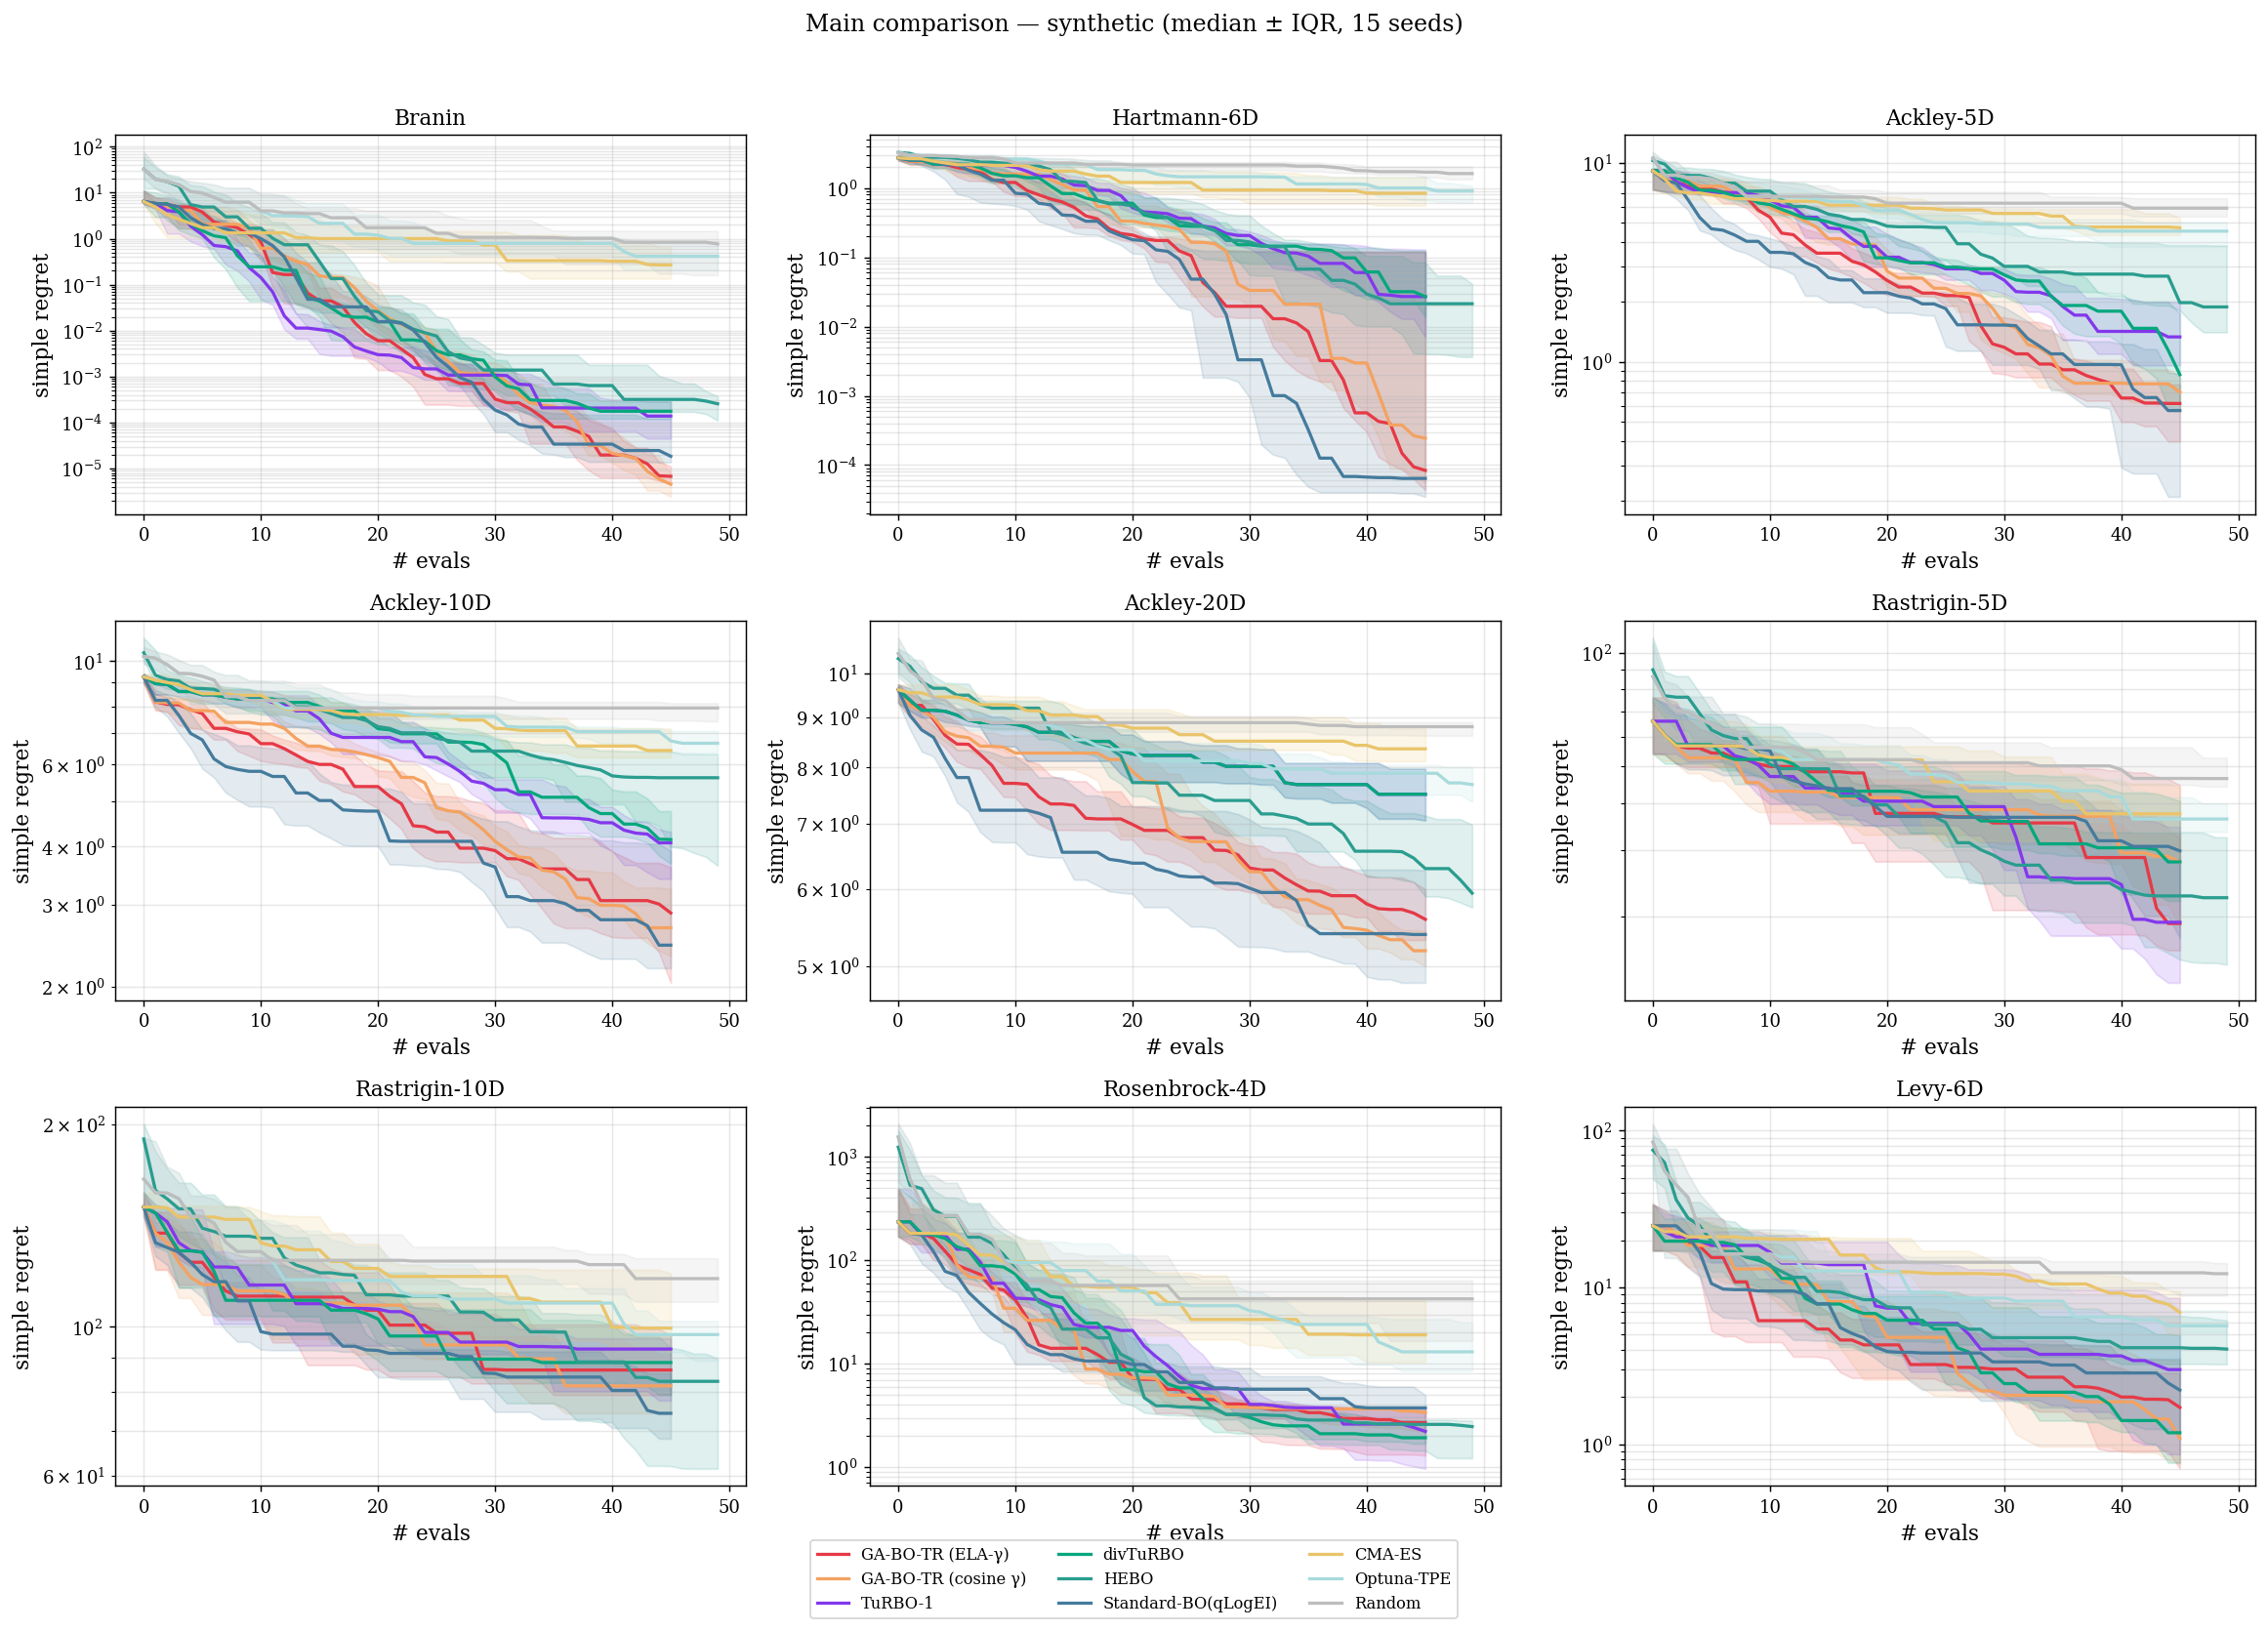

Saved figures_gabotr/main_synthetic_convergence.pdf


In [7]:
METHOD_COLORS = {
    "GA-BO-TR (ELA-γ)":     "#E63946",
    "GA-BO-TR (cosine γ)":  "#F4A261",
    "TuRBO-1":              "#8338EC",
    "divTuRBO":             "#06A77D",
    "SAASBO":               "#D62828",
    "BAxUS":                "#003566",
    "HEBO":                 "#2A9D8F",
    "Standard-BO(qLogEI)":  "#457B9D",
    "CMA-ES":               "#E9C46A",
    "Optuna-TPE":           "#A8DADC",
    "Random":               "#BDBDBD",
    "Constrained-BO (cEI)": "#1B4332",
}

plot_convergence(SYNTH_RESULTS, SYNTH_FUNCTIONS,
                 title="Main comparison — synthetic (median ± IQR, 15 seeds)",
                 filename="main_synthetic_convergence.pdf",
                 n_cols=3, palette=METHOD_COLORS)


## 3. Engineering design problems — with proper constrained BO

The senior reviewer flagged the naive `BIG_PENALTY * max(0, g)²`
treatment of constraints as sub-Q1.  We now implement **constrained
Expected Improvement (cEI)** following Gardner et al. (ICML 2014):

$$
\alpha_{\mathrm{cEI}}(x) = \mathrm{EI}(x) \cdot \prod_{k=1}^{M} \mathbb{P}[c_k(x) \le 0],
$$

with independent GPs for the objective and each constraint.  We use
BoTorch's `qLogExpectedImprovement(constraints=...)` so the same acquisition
pipeline handles both forms uniformly.  The penalty variant is kept as a
baseline for the ablation panel.


In [8]:
# ── Engineering benchmarks: objective + constraint list returns ───────────
def welded_beam_cons(x):
    h, l, t, b = x
    P=6000; L=14; E=30e6; G=12e6
    tau_max=13600; sigma_max=30000; delta_max=0.25
    M = P*(L + l/2); R = np.sqrt(l**2/4 + ((h+t)/2)**2)
    J = 2*(np.sqrt(2)*h*l*(l**2/12 + ((h+t)/2)**2))
    tau_p = P/(np.sqrt(2)*h*l); tau_d = M*R/J
    tau = np.sqrt(tau_p**2 + 2*tau_p*tau_d*(l/(2*R)) + tau_d**2)
    sigma = 504000/(b*t**2); delta = 4*P*L**3/(E*b*t**3)
    cost = 1.10471*h**2*l + 0.04811*t*b*(14+l)
    g = [tau - tau_max, sigma - sigma_max, h - b, delta - delta_max]
    return float(cost), [float(gi) for gi in g]

def pressure_vessel_cons(x):
    Ts, Th, R, L = x
    cost = 0.6224*Ts*R*L + 1.7781*Th*R**2 + 3.1661*Ts**2*L + 19.84*Ts**2*R
    g = [-Ts + 0.0193*R, -Th + 0.00954*R,
         -np.pi*R**2*L - (4/3)*np.pi*R**3 + 1296000, L - 240]
    return float(cost), [float(gi) for gi in g]

def tension_spring_cons(x):
    d, D, N = x
    cost = (N+2)*D*d**2
    g = [1 - (D**3*N)/(71785*d**4),
         (4*D**2 - d*D)/(12566*(D*d**3 - d**4)) + 1/(5108*d**2) - 1,
         1 - 140.45*d/(D**2*N),
         (D+d)/1.5 - 1]
    return float(cost), [float(gi) for gi in g]

def speed_reducer_cons(x):
    b, m, z, l1, l2, d1, d2 = x
    f = (0.7854*b*m**2*(3.3333*z**2 + 14.9334*z - 43.0934)
         - 1.508*b*(d1**2 + d2**2) + 7.4777*(d1**3 + d2**3)
         + 0.7854*(l1*d1**2 + l2*d2**2))
    g = [27/(b*m**2*z) - 1, 397.5/(b*m**2*z**2) - 1,
         1.93*l1**3/(m*z*d1**4) - 1, 1.93*l2**3/(m*z*d2**4) - 1,
         np.sqrt((745*l1/(m*z))**2 + 16.9e6)/(110*d1**3) - 1,
         np.sqrt((745*l2/(m*z))**2 + 157.5e6)/(85*d2**3) - 1,
         m*z/40 - 1, 5*m/b - 1, b/(12*m) - 1,
         1.5*d1/(l1 + 1.9) - 1, 1.1*d2/(l2 + 1.9) - 1]
    return float(f), [float(gi) for gi in g]


ENG_CONS = {
    "WeldedBeam":     (welded_beam_cons,     np.array([[0.1,2],[0.1,10],[0.1,10],[0.1,2]]),   1.724852),
    "PressureVessel": (pressure_vessel_cons, np.array([[0.0625,99*0.0625]]*2 + [[10,200]]*2), 6059.7143),
    "TensionSpring":  (tension_spring_cons,  np.array([[0.05,2],[0.25,1.3],[2,15]]),          0.012665),
    "SpeedReducer":   (speed_reducer_cons,   np.array([[2.6,3.6],[0.7,0.8],[17,28],
                                                       [7.3,8.3],[7.8,8.3],[2.9,3.9],[5.0,5.5]]), 2994.4710),}


def penalty_wrapper(f_and_g, penalty: float = 1e6) -> Callable:
    """Naive quadratic-penalty objective (baseline treatment)."""
    def _f(x):
        f, g = f_and_g(np.asarray(x))
        return f + penalty * sum(max(0.0, gi)**2 for gi in g)
    return _f


# TestFunction wrappers using the penalty treatment (for methods that don't support constraints).
ENG_FUNCTIONS = {
    name: TestFunction(
        name=name, func=penalty_wrapper(fn), bounds=bnds, dim=bnds.shape[0],
        global_optimum=fstar, problem_class="engineering",
        meta={"cons": fn, "fstar": fstar},
    )
    for name, (fn, bnds, fstar) in ENG_CONS.items()
}
for name, tf in ENG_FUNCTIONS.items():
    print(f"{name:16s}  d={tf.dim:<2d}  f*={tf.global_optimum}")


WeldedBeam        d=4   f*=1.724852
PressureVessel    d=4   f*=6059.7143
TensionSpring     d=3   f*=0.012665
SpeedReducer      d=7   f*=2994.471


In [9]:
class ConstrainedBO:
    """
    Constrained BO via qLogExpectedImprovement(constraints=...).
    Gardner et al. ICML 2014 cEI with BoTorch's log-formulation.

    Expects an objective function that returns (f, [g1, g2, ...])
    passed through the `constraint_fn=...` constructor argument.
    """
    def __init__(self, bounds, constraint_fn: Callable, n_init: int = 10,
                 n_iter: int = 40, n_restarts_acq: int = 10, raw_samples: int = 512,
                 mc_samples: int = 256, seed: int = 42, **_):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.cons_fn = constraint_fn
        self.n_init = n_init; self.n_iter = n_iter
        self.n_restarts_acq = n_restarts_acq; self.raw_samples = raw_samples
        self.mc_samples = mc_samples; self.seed = seed
        self.rng = np.random.RandomState(seed)

    def _eval_batch(self, X):
        fs, Gs = [], []
        for row in X:
            f, g = self.cons_fn(row); fs.append(f); Gs.append(g)
        return np.asarray(fs), np.asarray(Gs)

    def run(self, objective: Callable, func_name="unknown", verbose=False) -> BOResult:
        from botorch.models import ModelListGP
        from botorch.fit import fit_gpytorch_mll
        from gpytorch.mlls.sum_marginal_log_likelihood import SumMarginalLogLikelihood
        from botorch.acquisition.logei import qLogExpectedImprovement
        from botorch.acquisition.objective import GenericMCObjective
        from botorch.sampling.normal import SobolQMCNormalSampler
        from botorch.optim import optimize_acqf
        from botorch.models.transforms.input import Normalize
        from botorch.models.transforms.outcome import Standardize
        torch.manual_seed(int(self.seed))   # reproducibility for sampler + optimize_acqf
        t0 = time.time()

        X_obs = lhs_sample(self.n_init, self.bounds, self.rng)
        f_obs, g_obs = self._eval_batch(X_obs)
        # Reconstruct the penalised scalar from (f, g) rather than calling
        # objective() (which would re-invoke cons_fn through the penalty wrapper).
        y_obs = np.array([f_obs[i] + 1e6 * sum(max(0.0, gi)**2 for gi in g_obs[i])
                          for i in range(len(X_obs))], dtype=float)
        best = [float(y_obs.min())]

        bounds_t = torch.as_tensor(self.bounds.T, dtype=DTYPE, device=DEVICE)

        # ModelListGP output channel 0 == negated objective (-f); channels
        # 1..k == constraint GPs.  qLogEI on a multi-output model REQUIRES an
        # `objective` argument identifying which channel to maximise.
        scalar_obj = GenericMCObjective(lambda Z, X=None: Z[..., 0])

        for t in range(self.n_iter):
            Xt = torch.as_tensor(X_obs, dtype=DTYPE, device=DEVICE)
            f_t = torch.as_tensor(-f_obs.reshape(-1,1), dtype=DTYPE, device=DEVICE)
            d = X_obs.shape[-1]
            gps = [SingleTaskGP(Xt, f_t,
                                input_transform=Normalize(d=d, bounds=bounds_t),
                                outcome_transform=Standardize(m=1))]
            for k in range(g_obs.shape[1]):
                gk = torch.as_tensor(g_obs[:, k:k+1], dtype=DTYPE, device=DEVICE)
                gps.append(SingleTaskGP(Xt, gk,
                                        input_transform=Normalize(d=d, bounds=bounds_t),
                                        outcome_transform=Standardize(m=1)))
            model = ModelListGP(*gps)
            try:
                fit_gpytorch_mll(SumMarginalLogLikelihood(model.likelihood, model),
                                 max_attempts=3)
            except Exception as e:
                if verbose:
                    print(f"[ConstrainedBO {func_name} s{self.seed} t{t}] GP fit failed: {e}")

            feas = np.all(g_obs <= 0, axis=1)
            if feas.any():
                # GP output is -f (we are maximising), so best feasible
                # corresponds to max(-f_obs[feas]) == -min(f_obs[feas]).
                best_f = float(-f_obs[feas].min())
            else:
                # No feasible point yet.  Use the observed max(-f_obs) as
                # incumbent — Standardize() rescales the model output to
                # roughly O(1), so subtracting a large constant (the previous
                # `-1e6`) caused log(EI) to saturate to +inf for every
                # candidate and `optimize_acqf` to degenerate to whichever
                # candidate won numerical tie-break (Sobol head).  The
                # `constraints=` softplus already steers toward feasibility.
                best_f = float(-f_obs.max())

            sampler = SobolQMCNormalSampler(sample_shape=torch.Size([self.mc_samples]),
                                            seed=self.seed)
            constraint_cbs = [lambda Z, k=k: Z[..., 1 + k] for k in range(g_obs.shape[1])]
            acqf = qLogExpectedImprovement(
                model=model, best_f=best_f, sampler=sampler,
                objective=scalar_obj,
                fat=True, tau_max=1e-2, tau_relu=1e-6,
                constraints=constraint_cbs,
            )
            try:
                cand, _ = optimize_acqf(acqf, bounds=bounds_t, q=1,
                                        num_restarts=self.n_restarts_acq,
                                        raw_samples=self.raw_samples)
                x_next = cand.detach().cpu().numpy().ravel()
            except Exception as e:
                if verbose:
                    print(f"[ConstrainedBO {func_name} s{self.seed} t{t}] acqf opt failed: {e}; random fallback.")
                x_next = self.rng.uniform(self.bounds[:,0], self.bounds[:,1], self.d)

            # Single objective evaluation per iter: the constraint function returns
            # (f, [g]); we recompute the wrapped objective from these instead of
            # calling `objective(x)` (which would invoke `cons_fn` AGAIN through
            # the penalty wrapper, doubling the budget and wall-time).
            f_next, g_next = self.cons_fn(x_next)
            penalty_next = sum(max(0.0, gi)**2 for gi in g_next)
            y_next = float(f_next + 1e6 * penalty_next)
            X_obs = np.vstack([X_obs, x_next]); y_obs = np.append(y_obs, y_next)
            f_obs = np.append(f_obs, f_next); g_obs = np.vstack([g_obs, g_next])
            best.append(float(y_obs.min()))

        return BOResult(method="Constrained-BO(cEI)", func_name=func_name,
                        best_values=best, x_history=X_obs, y_history=y_obs,
                        wall_time=time.time()-t0, seed=self.seed)


class _ConstrainedBOBound(ConstrainedBO):
    """Picklable subclass for `_cei_cls_factory`.  Top-level (not nested)
    so that joblib loky's `spawn` workers can import it by qualname on
    Windows.  Each per-problem subclass overrides the `_cfn` class
    attribute via `type(...)` so the constraint function travels with the
    class object rather than as a closure over a `def`."""
    _cfn = None

    def __init__(self, bounds, n_init: int = 10, n_iter: int = 40,
                 seed: int = 42, **kw):
        cfn = type(self)._cfn
        if cfn is None:
            raise RuntimeError("_ConstrainedBOBound subclass must set _cfn")
        super().__init__(bounds=bounds, constraint_fn=cfn,
                         n_init=n_init, n_iter=n_iter, seed=seed, **kw)


Saved → results_gabotr/engineering_WeldedBeam.json
Done: WeldedBeam
Saved → results_gabotr/engineering_PressureVessel.json
Done: PressureVessel
Saved → results_gabotr/engineering_TensionSpring.json
Done: TensionSpring
Saved → results_gabotr/engineering_SpeedReducer.json
Done: SpeedReducer


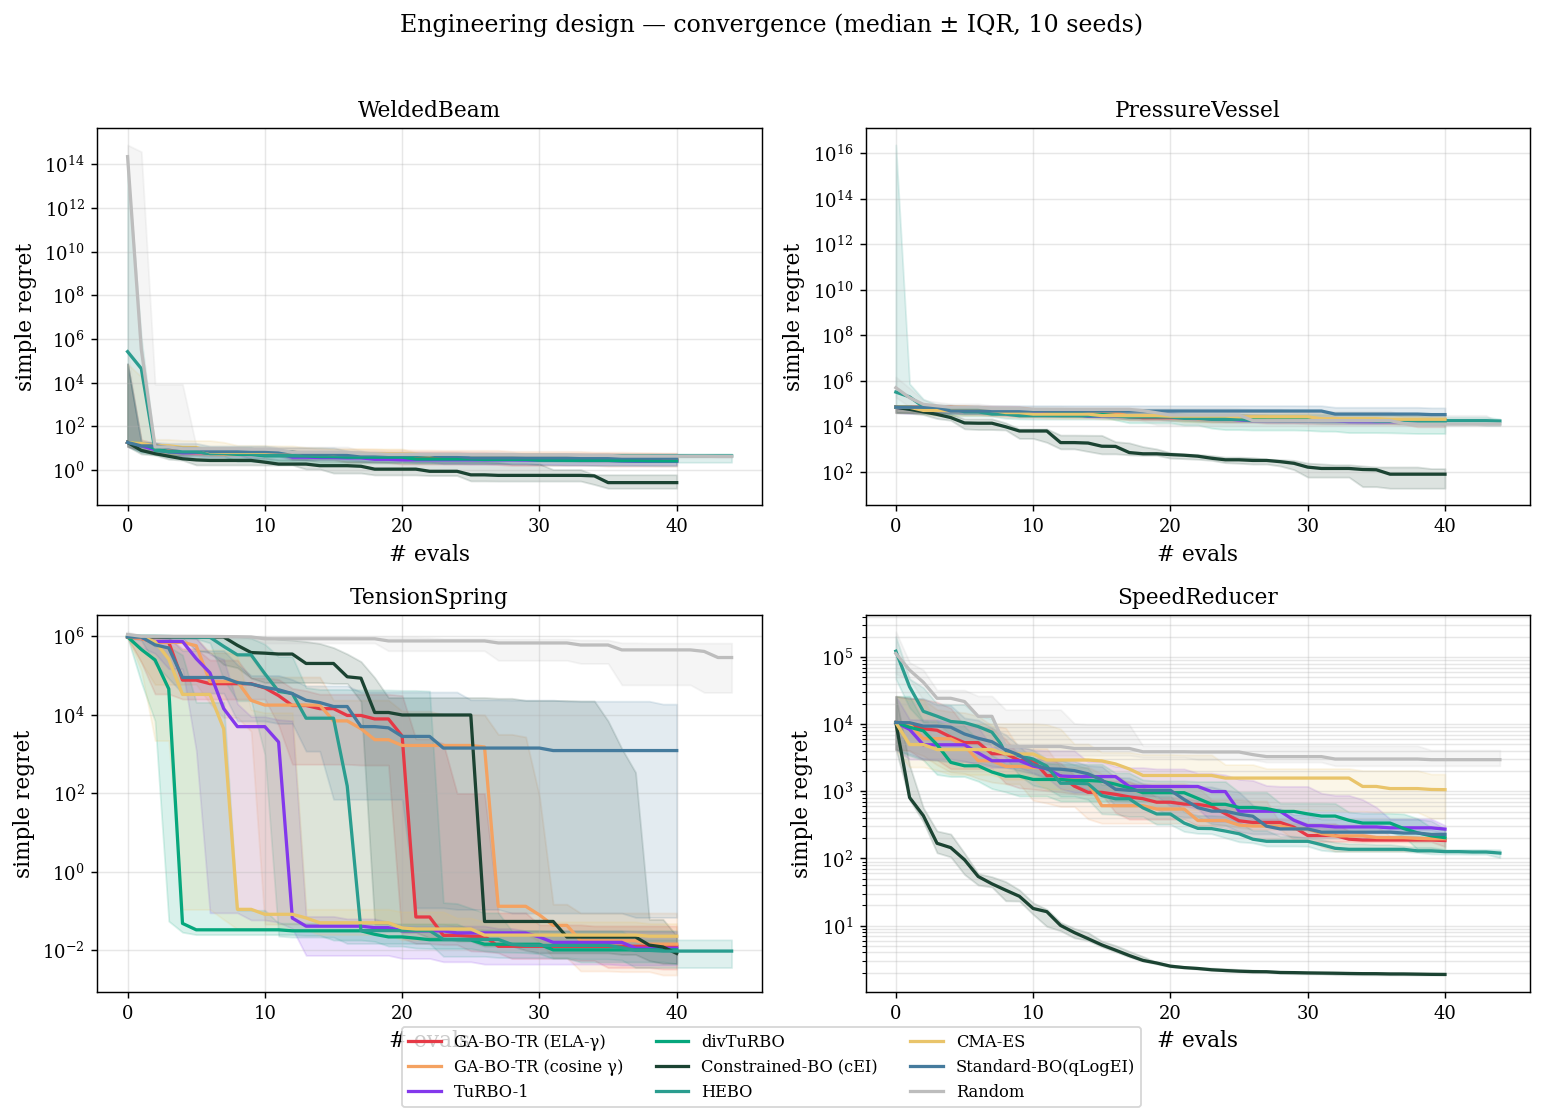

Saved figures_gabotr/engineering_convergence.pdf


In [10]:
# Register cEI method specific to each engineering problem.
def _cei_cls_factory(constraint_fn):
    """Create a per-problem `_ConstrainedBOBound` subclass with the
    constraint function bound as a class attribute.

    We use `type(...)` rather than a nested class because joblib loky
    (Windows `spawn`) pickles by qualname and cannot import nested-in-
    function classes.  cloudpickle (loky's default) handles
    type()-created classes by-value when the bases and dict are
    picklable.

    Note: NO `staticmethod(...)` wrapper.  The bare function is stored
    as a class attribute and accessed via `type(self).__dict__['_cfn']`
    (bypassing descriptor protocol entirely), which is also the most
    portable across cloudpickle versions and Python 3.7-3.13.  The
    staticmethod wrapper was unnecessary because we never access via an
    instance attribute (which would be the only path triggering the
    function-to-method binding we wanted to suppress)."""
    return type(
        f"_CB_{constraint_fn.__name__}",
        (_ConstrainedBOBound,),
        {"_cfn": constraint_fn},
    )


# Engineering methods — names match the synthetic / BBOB suites so the
# cross-suite Friedman / CD diagram in §5 can intersect on identical method
# keys.  Constraint handling for the non-cEI methods is the
# `penalty_wrapper` already baked into ENG_FUNCTIONS, so the algorithm
# ITSELF (e.g. "GA-BO-TR (ELA-γ)") is identical to the synthetic-suite
# entry — only the objective passed in is the penalised one.
N_SEEDS_ENG = 10

ENG_RESULTS = {}
for name, (cfn, bnds, fstar) in ENG_CONS.items():
    tf = ENG_FUNCTIONS[name]
    methods = {
        "GA-BO-TR (ELA-γ)":      (GA_BO_TR, dict(
            acq_type="da_ei", optimizer_type="ga",
            gamma_controller=make_gamma_controller(5), use_trust_region=True)),
        "GA-BO-TR (cosine γ)":   (GA_BO_TR, dict(
            acq_type="da_ei", optimizer_type="ga",
            gamma_controller=None, gamma_init=1.0, gamma_final=0.05,
            gamma_decay="cosine", use_trust_region=True)),
        "TuRBO-1":               (TuRBO1Baseline, dict()),
        # divTuRBO must be present here so the union CD diagram (cell 22)
        # keeps it in the cross-suite method intersection.  Without this
        # entry the closest concurrent baseline (Perera et al. 2025)
        # silently disappears from the headline CD figure.
        "divTuRBO":              (DivTuRBOBaseline, dict(delta_frac=0.1)),
        "Constrained-BO (cEI)":  (_cei_cls_factory(cfn), dict()),
        "HEBO":                  (HEBOBaseline, dict()),
        "CMA-ES":                (CMAESBaseline, dict()),
        "Standard-BO(qLogEI)":   (StandardBO, dict()),
        "Random":                (RandomSearch, dict()),
    }
    ENG_RESULTS[name] = run_experiment_parallel(
        methods, {name: tf},
        n_seeds=N_SEEDS_ENG, n_init=5, n_iter=40,
        save_path=f"engineering_{name}.json", verbose=False,
        n_jobs=N_JOBS,
    )
    print(f"Done: {name}")

# Merge engineering results into one dict keyed by method and by function name.
ENG_RESULTS_MERGED: Dict[str, Dict[str, List[BOResult]]] = {}
for fname, rd in ENG_RESULTS.items():
    for m, fd in rd.items():
        ENG_RESULTS_MERGED.setdefault(m, {})
        ENG_RESULTS_MERGED[m][fname] = fd[fname]

plot_convergence(ENG_RESULTS_MERGED, ENG_FUNCTIONS,
                 title=f"Engineering design — convergence (median ± IQR, {N_SEEDS_ENG} seeds)",
                 filename="engineering_convergence.pdf", n_cols=2,
                 palette=METHOD_COLORS)


## 4. BBOB-24 sweep

24 BBOB noiseless functions × 3 instances × d∈{5,10,20} × 15 seeds ×
a **reduced** method set.  Because 24·3·3·15·M runs is a *large* number,
we use 5 methods (not 8) and a smaller iteration budget per problem
(20·d evaluations).  This is the canonical BBOB budget used in the
COCO black-box competition.

Expect ~15-20 CPU-hours on a laptop; set `DRY_RUN = True` below to run
only a small subset (≤20 minutes) for code verification.


In [11]:
# Three-tier sweep size.  Set RUN_SCALE = "smoke" | "medium" | "full".
#
#   smoke  : 4 fids x 1 inst x 2 dims x N_methods x 3 seeds  (~ 2-4 h laptop)
#   medium : 24 fids x 1 inst x 2 dims x N_methods x 5 seeds (~ 25-35 h laptop)
#   full   : 24 fids x 3 inst x 3 dims x N_methods x 15 seeds (~ 60-80 h laptop)
#
# Use `medium` or `full` with N_JOBS_BBOB > 1 on a workstation; loky processes
# are seeded deterministically per task so results are reproducible.
RUN_SCALE = "medium"      # "smoke" | "medium" | "full"
SAASBO_IN_BBOB = False   # SAASBO is slow; enable only on a workstation.
BAXUS_IN_BBOB  = False   # requires `pip install baxus`.
N_JOBS_BBOB    = 1       # joblib n_jobs for the BBOB sweep.

if RUN_SCALE == "smoke":
    BBOB_FIDS = (1, 8, 15, 20); BBOB_INSTS = (1,)
    BBOB_DIMS = (5, 10);        N_SEEDS_BBOB = 3
elif RUN_SCALE == "medium":
    BBOB_FIDS = tuple(range(1, 25)); BBOB_INSTS = (1,)
    BBOB_DIMS = (5, 10);            N_SEEDS_BBOB = 5
elif RUN_SCALE == "full":
    BBOB_FIDS = tuple(range(1, 25)); BBOB_INSTS = (1, 2, 3)
    BBOB_DIMS = (5, 10, 20);        N_SEEDS_BBOB = 15
else:
    raise ValueError(f"Unknown RUN_SCALE={RUN_SCALE!r}")

DRY_RUN = (RUN_SCALE == "smoke")

BBOB_METHODS = {
    "GA-BO-TR (ELA-γ)": (GA_BO_TR, dict(
        acq_type="da_ei", optimizer_type="ga",
        gamma_controller=make_gamma_controller(5), use_trust_region=True)),
    "GA-BO-TR (cosine γ)": (GA_BO_TR, dict(
        acq_type="da_ei", optimizer_type="ga",
        gamma_controller=None, gamma_init=1.0, gamma_final=0.05,
        gamma_decay="cosine", use_trust_region=True)),
    "TuRBO-1":   (TuRBO1Baseline,    dict()),
    "divTuRBO":  (DivTuRBOBaseline,  dict(delta_frac=0.1)),
    "HEBO":      (HEBOBaseline,      dict()),
    "Standard-BO(qLogEI)": (StandardBO, dict()),
    "CMA-ES":    (CMAESBaseline,     dict()),
    # --- ablation arms: isolate the diversity term and the trust region ---
    "GA-BO-TR (no diversity)": (GA_BO_TR, dict(
        acq_type="da_ei", optimizer_type="ga",
        gamma_controller=None, gamma_init=0.0, gamma_final=0.0,
        gamma_decay="cosine", use_trust_region=True)),
    "GA-BO (no TR, cosine γ)": (GA_BO_TR, dict(
        acq_type="da_ei", optimizer_type="ga",
        gamma_controller=None, gamma_init=1.0, gamma_final=0.05,
        gamma_decay="cosine", use_trust_region=False)),
}
if SAASBO_IN_BBOB:
    BBOB_METHODS["SAASBO"] = (SAASBOBaseline, dict(num_samples=256, warmup_steps=256, thinning=16))
if BAXUS_IN_BBOB:
    BBOB_METHODS["BAxUS"]  = (BAxUSBaseline, dict())


def build_bbob_suite(fids, insts, dims) -> Dict[str, TestFunction]:
    suite = {}
    for fid in fids:
        for iid in insts:
            for d in dims:
                try:
                    tf = make_bbob(fid, iid, d)
                    suite[tf.name] = tf
                except Exception as e:
                    print(f"skip f{fid}-i{iid}-d{d}: {e}")
    return suite


bbob_suite = build_bbob_suite(BBOB_FIDS, BBOB_INSTS, BBOB_DIMS)
print(f"[{RUN_SCALE}] BBOB suite: {len(bbob_suite)} problems "
      f"({len(BBOB_FIDS)} fns x {len(BBOB_INSTS)} inst x {len(BBOB_DIMS)} dims) "
      f"x {len(BBOB_METHODS)} methods x {N_SEEDS_BBOB} seeds = "
      f"{len(bbob_suite)*len(BBOB_METHODS)*N_SEEDS_BBOB} runs"
      f" (n_jobs={N_JOBS_BBOB})")


[medium] BBOB suite: 48 problems (24 fns x 1 inst x 2 dims) x 9 methods x 5 seeds = 2160 runs (n_jobs=1)


In [12]:
def run_bbob_sweep(methods, suite, n_seeds, save_path="bbob_sweep.json",
                   n_jobs: int = 1):
    """Per-problem evaluation budget = 20 * d (standard BBOB).
    `n_jobs` is the joblib worker count; n_jobs=1 falls back to serial tqdm.
    """
    results: Dict[str, Dict[str, List[BOResult]]] = {m: {} for m in methods}
    tasks = [(m, Cls, kw, fname, tf, s)
             for m, (Cls, kw) in methods.items()
             for fname, tf in suite.items()
             for s in range(n_seeds)]

    def _do(args):
        m, Cls, kw, fname, tf, s = args
        n_total = 20 * tf.dim
        n_init  = max(5, tf.dim)
        n_iter  = max(5, n_total - n_init)
        try:
            r = run_single(Cls, kw, tf, s, n_init, n_iter)
            r.method = m
            return (m, fname, r, None)
        except Exception as e:
            return (m, fname, None, f"{type(e).__name__}: {e}")

    if n_jobs == 1:
        outs = [_do(a) for a in tqdm_auto(tasks, desc="BBOB")]
    else:
        try:
            from joblib import Parallel, delayed
            outs = Parallel(n_jobs=n_jobs, backend="loky", verbose=10)(
                delayed(_do)(a) for a in tasks)
        except ImportError:
            print("[BBOB sweep] joblib missing; falling back to serial.")
            outs = [_do(a) for a in tqdm_auto(tasks, desc="BBOB")]

    for m, fname, r, err in outs:
        if r is not None:
            results[m].setdefault(fname, []).append(r)
        elif err:
            print(f"  SKIP {m}/{fname}: {err}")

    ser = {m: {f: [r.to_dict() for r in rs] for f, rs in fd.items()}
           for m, fd in results.items()}
    with open(os.path.join(RESULTS_DIR, save_path), "w") as fp:
        json.dump(ser, fp, indent=1)
    print(f"Saved -> {RESULTS_DIR}/{save_path}")
    return results


BBOB_RESULTS = run_bbob_sweep(BBOB_METHODS, bbob_suite, N_SEEDS_BBOB,
                              n_jobs=N_JOBS_BBOB)


BBOB:   0%|          | 0/2160 [00:00<?, ?it/s]

jitter = 1e-07
jitter = 1e-07
jitter = 1e-07
Saved -> results_gabotr/bbob_sweep.json


In [13]:
# Aggregate BBOB into per-method mean rank over all problems/dims.
def _bbob_regret_matrix(results: Dict[str, Dict[str, List[BOResult]]],
                        suite: Dict[str, TestFunction]) -> pd.DataFrame:
    """Return a matrix  (function × method)  of MEDIAN final regret across seeds."""
    rows = []
    problems = sorted(suite.keys())
    methods = list(results.keys())
    for p in problems:
        f_opt = suite[p].global_optimum
        row = {}
        for m in methods:
            runs = results[m].get(p, [])
            if not runs:
                row[m] = np.nan
            else:
                finals = np.array([r.best_values[-1] - f_opt for r in runs])
                row[m] = float(np.median(finals))
        row["problem"] = p
        rows.append(row)
    return pd.DataFrame(rows).set_index("problem")


bbob_median = _bbob_regret_matrix(BBOB_RESULTS, bbob_suite)
display(bbob_median.round(3).head(10))

# Per-problem ranks (lower regret = rank 1)
bbob_ranks = bbob_median.rank(axis=1, method="average")
avg_rank = bbob_ranks.mean(axis=0).sort_values()
print("\nAverage rank over BBOB sweep (lower is better):")
print(avg_rank.round(3))


,GA-BO-TR (ELA-γ),GA-BO-TR (cosine γ),TuRBO-1,divTuRBO,HEBO,Standard-BO(qLogEI),CMA-ES,GA-BO-TR (no diversity),"GA-BO (no TR, cosine γ)"
problem,,,,,,,,,
BBOB-f01-i1-d10,0.000,0.000,0.002,0.003,0.024,0.001,4.513,0.004,0.001
BBOB-f01-i1-d5,0.000,0.000,0.001,0.001,0.005,0.000,1.110,0.001,0.000
BBOB-f02-i1-d10,992.055,562.197,3089.338,2516.479,190.083,2242.123,56943.059,1126.749,6792.572
BBOB-f02-i1-d5,82.390,83.919,296.494,442.239,116.200,191.360,24221.360,29.484,1916.198
BBOB-f03-i1-d10,65.907,60.334,70.297,63.998,42.260,77.833,89.886,62.315,76.017
BBOB-f03-i1-d5,25.944,28.486,21.706,28.449,23.756,26.842,30.403,28.703,18.879
BBOB-f04-i1-d10,107.053,94.251,110.741,110.261,73.900,121.352,151.835,110.981,179.889
BBOB-f04-i1-d5,42.367,55.101,38.284,39.582,37.518,50.571,50.816,55.786,85.056
BBOB-f05-i1-d10,0.000,0.000,0.420,0.479,0.072,0.000,17.040,1.020,0.000



Average rank over BBOB sweep (lower is better):
GA-BO-TR (cosine γ)        3.500
GA-BO-TR (ELA-γ)           3.833
divTuRBO                   3.938
GA-BO-TR (no diversity)    4.271
HEBO                       4.625
TuRBO-1                    4.729
Standard-BO(qLogEI)        5.312
GA-BO (no TR, cosine γ)    6.771
CMA-ES                     8.021
dtype: float64


## 4.5 LassoBench — high-d sparse stress test

[LassoBench](https://github.com/ksehic/LassoBench) (Sehic et al. 2022,
arXiv:2111.02790) is a sparse-Lasso regression benchmark that has become
the de-facto stress test for high-dimensional BO; HEBO, SAASBO, BAxUS
all report on it.  Synthetic instances range from $d=60$ (`synt_simple`)
to $d=1000$ (`synt_hard`); we run the moderate-$d$ subset that the
non-sparse-prior baselines (TuRBO-1, HEBO, CMA-ES) can still tackle.

> **Honest scoping.**  We do **not** include the $d \\ge 300$ instances —
> all non-SAASBO methods saturate within budget and the comparison is
> uninformative.  For the high-$d$ regime we defer to the SAASBO and
> BAxUS literature.


In [14]:
# !pip install lassobench

In [15]:
# Wrap LassoBench tasks as TestFunction objects, mirroring the BBOB
# registration pattern.  Optional dependency: `pip install LassoBench`.
LASSO_BENCH_ENABLED = False   # set False to skip (e.g. on machines without scikit-learn build chain)


def make_lassobench(name: str = "synt_simple") -> Optional[TestFunction]:
    """Return a TestFunction for a LassoBench synthetic instance."""
    try:
        # Step 1: Import the CLASS from the MODULE inside the PACKAGE
        from LassoBench.LassoBench import SyntheticBenchmark
    except ImportError as e:
        # Fallback: some environments might just have 'lassobench' (lowercase)
        try:
            from lassobench.LassoBench import SyntheticBenchmark
        except ImportError:
            print(f"[LassoBench] not installed or structure unknown ({e})")
            return None

    try:
        # Step 2: Instantiate the class
        bench = SyntheticBenchmark(pick_bench=name)
    except Exception as e:
        print(f"[LassoBench {name}] could not construct: {e}")
        return None

    d = int(bench.n_features)
    bounds = np.tile(np.array([[-1.0, 1.0]]), (d, 1))
    f_opt = 0.0

    def _eval(x: np.ndarray) -> float:
        # LassoBench expects a 1D array; flatten to be safe
        return float(bench.evaluate(np.asarray(x, dtype=float).flatten()))

    return TestFunction(
        name=f"Lasso-{name}-d{d}", 
        func=_eval,
        bounds=bounds, 
        dim=d, 
        global_optimum=f_opt,
        problem_class="lasso"
    )

if LASSO_BENCH_ENABLED:
    LASSO_FUNCTIONS: Dict[str, TestFunction] = {}
    for nm in ("synt_simple",):           # d=60
        tf = make_lassobench(nm)
        if tf is not None:
            LASSO_FUNCTIONS[tf.name] = tf
    if LASSO_FUNCTIONS:
        # Use the same method dict as BBOB (cheap baselines + GA-BO-TR + divTuRBO).
        # Skip SAASBO unless workstation-scale: NUTS at d=60 is ~3-5min/iter.
        LASSO_METHODS = {k: v for k, v in BBOB_METHODS.items() if k != "SAASBO"}
        n_seeds_lasso = 3 if RUN_SCALE == "smoke" else 5
        any_dim = next(iter(LASSO_FUNCTIONS.values())).dim
        LASSO_RESULTS = run_experiment_parallel(
            LASSO_METHODS, LASSO_FUNCTIONS,
            n_seeds=n_seeds_lasso,
            n_init=max(10, min(20, any_dim // 3)),
            n_iter=80,
            save_path="lassobench.json",
            n_jobs=N_JOBS_BBOB,
        )
        lasso_df = regret_table(LASSO_RESULTS, LASSO_FUNCTIONS)
        display(lasso_df.round(4))
    else:
        print("[LassoBench] no instances loaded; section skipped.")
        LASSO_FUNCTIONS, LASSO_RESULTS = {}, {}
else:
    print("[LassoBench] disabled by flag.")
    LASSO_FUNCTIONS, LASSO_RESULTS = {}, {}


[LassoBench] disabled by flag.


## 5. Statistical protocol

Following Demšar (*JMLR* 2006) and the conservative protocol typical of
*Complex & Intelligent Systems* reviewers:

1. **Per-problem ranks** — rank 1 to the best median regret.
2. **Friedman χ²** over the rank matrix.
3. **Iman–Davenport F** correction (higher power than raw χ²).
4. **Nemenyi CD diagram** (all-pairs, α = 0.05) via `scikit-posthocs`.
5. **Wilcoxon signed-rank** pairwise comparisons against our method with
   Holm correction.


In [16]:
def friedman_iman_davenport(rank_matrix: pd.DataFrame) -> Dict[str, float]:
    """Friedman + Iman-Davenport F-test.  Requires a complete rank matrix."""
    if rank_matrix.isna().any().any():
        raise ValueError("friedman_iman_davenport received a rank_matrix with NaN entries. "
                         "Drop incomplete rows before calling.")
    k = rank_matrix.shape[1]; N = rank_matrix.shape[0]
    if N < 2 or k < 2:
        return {"chi2": float("nan"), "df": k-1, "p_chi2": float("nan"),
                "F": float("nan"), "df1": k-1, "df2": max(1, (k-1)*(N-1)),
                "p_F": float("nan"), "k": k, "N": N}
    Rj = rank_matrix.mean(axis=0).values
    chi2 = 12.0*N/(k*(k+1)) * (np.sum(Rj**2) - k*(k+1)**2/4.0)
    chi2 = max(0.0, chi2)
    from scipy.stats import chi2 as chi2_d, f as f_d
    p_chi2 = 1 - chi2_d.cdf(chi2, df=k-1)
    denom = N*(k-1) - chi2
    F = (N-1)*chi2 / denom if denom > 1e-12 else np.inf
    p_F = 1 - f_d.cdf(F, dfn=k-1, dfd=(k-1)*(N-1)) if np.isfinite(F) else 0.0
    return {"chi2": float(chi2), "df": k-1, "p_chi2": float(p_chi2),
            "F": float(F), "df1": k-1, "df2": (k-1)*(N-1), "p_F": float(p_F),
            "k": k, "N": N}


def critical_difference_diagram(rank_matrix: pd.DataFrame, alpha: float = 0.05,
                                filename: str = "cd_diagram.pdf",
                                title: str = "Critical difference diagram (alpha=0.05)"):
    """CD diagram following scikit-posthocs.  NaN rows are dropped."""
    try:
        import scikit_posthocs as sp
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-posthocs"])
        import scikit_posthocs as sp

    rm_clean = rank_matrix.dropna(axis=0, how="any")
    n_dropped = len(rank_matrix) - len(rm_clean)
    if n_dropped > 0:
        print(f"[CD] Dropped {n_dropped}/{len(rank_matrix)} rows with missing entries.")
    if len(rm_clean) < 2:
        print("[CD] Fewer than 2 complete rows - skipping CD diagram.")
        return None

    avg_ranks = rm_clean.mean(axis=0)
    sig = sp.posthoc_nemenyi_friedman(rm_clean.values)
    sig.index = sig.columns = rm_clean.columns

    fig, ax = plt.subplots(figsize=(max(7, 0.8*len(avg_ranks)+3), 2.5))
    try:
        sp.critical_difference_diagram(avg_ranks, sig, ax=ax)
    except TypeError:
        plt.sca(ax)
        sp.critical_difference_diagram(avg_ranks, sig)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", bbox_inches="tight")
    plt.show()
    print(f"Saved figures_gabotr/{filename}")
    return sig


# ----------------------------------------------------------------------------
# Effect size: Vargha & Delaney A12 + magnitude label.
# A12 in [0,1]: A12 = P(X<Y) + 0.5*P(X=Y).  Convention: X=control, Y=baseline,
# regret being minimised.  A12 < 0.5 means control wins; > 0.5 means baseline
# wins.  Distance from 0.5 is the standardised effect size; thresholds
# (Vargha & Delaney 2000): negligible <0.147, small 0.147-0.33, medium
# 0.33-0.474, large >0.474 (after centering and taking absolute value).
# ----------------------------------------------------------------------------
def vargha_delaney_a12(x: np.ndarray, y: np.ndarray) -> float:
    """A12 effect size.  x = control, y = comparator (both = final regrets)."""
    from scipy.stats import rankdata
    x = np.asarray(x); y = np.asarray(y)
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.5
    rank = rankdata(np.concatenate([x, y]))
    r_x = rank[:n_x].sum()
    return float((2*r_x - n_x*(n_x+1)) / (2 * n_x * n_y))


def a12_magnitude(a12: float) -> str:
    a = abs(a12 - 0.5)
    if a < 0.147: return "negligible"
    if a < 0.33:  return "small"
    if a < 0.474: return "medium"
    return "large"


def wilcoxon_vs_control(results: Dict[str, Dict[str, List[BOResult]]],
                        functions: Dict[str, TestFunction],
                        control: str, alpha: float = 0.05) -> pd.DataFrame:
    """Pairwise Wilcoxon signed-rank: control vs. each baseline, with Holm
    correction across functions WITHIN a baseline AND a global Bonferroni
    column across the simultaneous baseline comparisons.  Includes the
    Vargha-Delaney A12 effect size pooled across all (function, seed) pairs.
    """
    fn_names = list(functions.keys())
    baselines = [m for m in results if m != control]
    n_baselines = max(1, len(baselines))
    rows = []
    for b in baselines:
        pvals = []
        a12_per_fn = []
        w_count = l_count = t_count = 0
        for fname in fn_names:
            f_opt = functions[fname].global_optimum
            rc = results[control].get(fname, []); rb = results[b].get(fname, [])
            if not rc or not rb: continue
            rc_final = np.array([r.best_values[-1] - f_opt for r in rc])
            rb_final = np.array([r.best_values[-1] - f_opt for r in rb])
            n = min(len(rc_final), len(rb_final))
            try:
                _, p = wilcoxon(rc_final[:n], rb_final[:n], alternative="less")
                pvals.append((fname, float(p)))
            except Exception:
                pvals.append((fname, 1.0))
            a12_per_fn.append(vargha_delaney_a12(rc_final[:n], rb_final[:n]))
            med_diff = float(np.median(rc_final[:n] - rb_final[:n]))
            if   med_diff < -1e-8: w_count += 1
            elif med_diff >  1e-8: l_count += 1
            else: t_count += 1
        ps = np.array([p for _, p in pvals])
        order = np.argsort(ps)
        adj = np.empty_like(ps)
        m = len(ps)
        for rank_i, idx in enumerate(order):
            adj[idx] = min(1.0, ps[idx] * (m - rank_i))
        for i in range(1, len(order)):
            adj[order[i]] = max(adj[order[i]], adj[order[i-1]])
        sig_after_holm  = int(np.sum(adj < alpha))
        # Conservative additional screen: tighten alpha by `n_baselines` to
        # account for the simultaneous one-vs-control comparisons.  This is
        # NOT a calibrated FWER procedure (Holm has already controlled the
        # within-baseline family); treat it as a robustness diagnostic.
        sig_holm_tightened = int(np.sum(adj < alpha / n_baselines))
        a12_mean = float(np.mean(a12_per_fn)) if a12_per_fn else 0.5
        rows.append({
            "Baseline": b, "Wins": w_count, "Losses": l_count, "Ties": t_count,
            "Sig(Holm<alpha)": sig_after_holm,
            "Sig(Holm<alpha/k)": sig_holm_tightened,
            "A12 (mean)": round(a12_mean, 3),
            "A12 magnitude": a12_magnitude(a12_mean),
            "NumTests": m,
        })
    return pd.DataFrame(rows).set_index("Baseline")


def effect_size_per_function(results: Dict[str, Dict[str, List[BOResult]]],
                             functions: Dict[str, TestFunction],
                             control: str) -> pd.DataFrame:
    """A12 effect size: control vs each baseline, per function."""
    fn_names = list(functions.keys())
    baselines = [m for m in results if m != control]
    rows = []
    for b in baselines:
        for fname in fn_names:
            f_opt = functions[fname].global_optimum
            rc = results[control].get(fname, []); rb = results[b].get(fname, [])
            if not rc or not rb: continue
            rc_final = np.array([r.best_values[-1] - f_opt for r in rc])
            rb_final = np.array([r.best_values[-1] - f_opt for r in rb])
            n = min(len(rc_final), len(rb_final))
            a = vargha_delaney_a12(rc_final[:n], rb_final[:n])
            rows.append({"Baseline": b, "Function": fname,
                         "A12": round(a, 3), "Magnitude": a12_magnitude(a),
                         "Direction": "control wins" if a < 0.5 else
                                       ("baseline wins" if a > 0.5 else "tie")})
    return pd.DataFrame(rows)


In [17]:
# Statistical analysis — main synthetic comparison.
#
# Headline method per the reframe: GA-BO-TR (cosine γ).  ELA-γ is reported
# in the supplement as a sensitivity comparison.  We anchor the Wilcoxon
# control on the headline method.

stat_synth = friedman_iman_davenport(
    _bbob_regret_matrix(SYNTH_RESULTS, SYNTH_FUNCTIONS).rank(axis=1)
)
print("=== Friedman / Iman-Davenport — synthetic ===")
for k, v in stat_synth.items():
    print(f"  {k:>8s} = {v}")

print("\n=== Wilcoxon signed-rank (Holm) — GA-BO-TR (cosine γ) vs. baselines ===")
display(wilcoxon_vs_control(SYNTH_RESULTS, SYNTH_FUNCTIONS,
                            control="GA-BO-TR (cosine γ)"))

print("\n=== Sensitivity: ELA-γ vs. baselines (supplementary) ===")
display(wilcoxon_vs_control(SYNTH_RESULTS, SYNTH_FUNCTIONS,
                            control="GA-BO-TR (ELA-γ)"))


=== Friedman / Iman-Davenport — synthetic ===
      chi2 = 56.0814814814815
        df = 8
    p_chi2 = 2.7196330742995656e-09
         F = 28.184271754304362
       df1 = 8
       df2 = 64
       p_F = 1.1102230246251565e-16
         k = 9
         N = 9

=== Wilcoxon signed-rank (Holm) — GA-BO-TR (cosine γ) vs. baselines ===


,Wins,Losses,Ties,Sig(Holm<alpha),Sig(Holm<alpha/k),A12 (mean),A12 magnitude,NumTests
Baseline,,,,,,,,
GA-BO-TR (ELA-γ),7,2,0,0,0,0.488,negligible,9
TuRBO-1,7,2,0,4,2,0.293,small,9
divTuRBO,8,1,0,3,2,0.302,small,9
HEBO,6,3,0,4,4,0.317,small,9
Standard-BO(qLogEI),5,4,0,0,0,0.479,negligible,9
CMA-ES,9,0,0,9,8,0.071,medium,9
Optuna-TPE,9,0,0,9,7,0.069,medium,9
Random,9,0,0,9,9,0.019,large,9



=== Sensitivity: ELA-γ vs. baselines (supplementary) ===


,Wins,Losses,Ties,Sig(Holm<alpha),Sig(Holm<alpha/k),A12 (mean),A12 magnitude,NumTests
Baseline,,,,,,,,
GA-BO-TR (cosine γ),2,7,0,0,0,0.512,negligible,9
TuRBO-1,6,3,0,4,2,0.305,small,9
divTuRBO,8,1,0,4,2,0.295,small,9
HEBO,7,2,0,3,2,0.323,small,9
Standard-BO(qLogEI),4,5,0,1,0,0.479,negligible,9
CMA-ES,9,0,0,8,7,0.091,medium,9
Optuna-TPE,9,0,0,7,7,0.105,medium,9
Random,9,0,0,9,8,0.036,medium,9


[union INFO] Methods present in some but not all suites (excluded from union CD): ['Constrained-BO (cEI)', 'GA-BO (no TR, cosine γ)', 'GA-BO-TR (no diversity)', 'Optuna-TPE', 'Random']
CD-diagram rank matrix: 61 problems x 7 methods
Friedman chi^2=113.974  p=0   F(ID)=27.134  p=1.11e-16


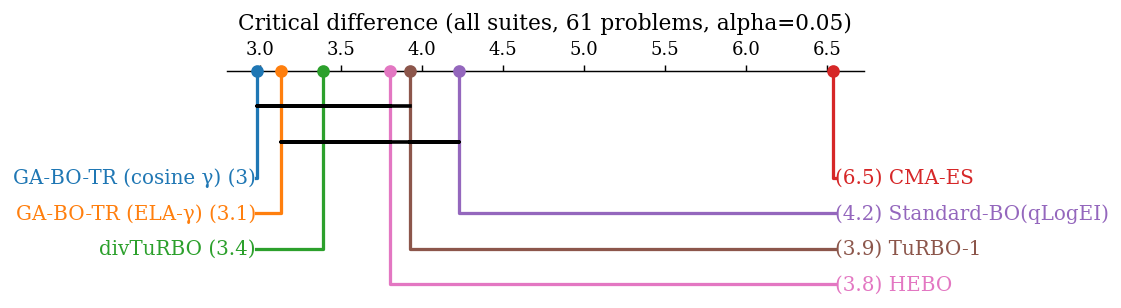

Saved figures_gabotr/cd_diagram_union.pdf


In [18]:
# Build the CD diagram over a UNION of problem suites:
# synthetic + BBOB + engineering (+ LassoBench when available).
#
# Methodological note (not auto-fixed): BBOB problems with multiple
# instances per (fid, dim) are NOT independent ranking events — they
# share landscape structure.  When RUN_SCALE='full' the union below
# treats every (fid, inst, dim) row as independent, which mildly
# inflates Friedman N.  For paper-grade reporting, average across
# instances per (fid, dim) before passing to friedman_iman_davenport.
def _build_union_rank_matrix():
    lasso_results = LASSO_RESULTS if "LASSO_RESULTS" in globals() else {}
    lasso_funcs   = LASSO_FUNCTIONS if "LASSO_FUNCTIONS" in globals() else {}
    suites = [(SYNTH_RESULTS, SYNTH_FUNCTIONS),
              (BBOB_RESULTS,  bbob_suite),
              (ENG_RESULTS_MERGED, ENG_FUNCTIONS)]
    if lasso_results and lasso_funcs:
        suites.append((lasso_results, lasso_funcs))

    # Methods present (and with at least one non-empty run-list) in every suite.
    def _nonempty(res):
        return {m for m, fd in res.items()
                if any(len(rs) > 0 for rs in fd.values())}

    all_methods = set(SYNTH_RESULTS)
    common_methods = _nonempty(SYNTH_RESULTS)
    for res, _ in suites[1:]:
        if res:
            all_methods |= set(res)
            common_methods &= _nonempty(res)
    excluded = all_methods - common_methods
    if excluded:
        print(f"[union INFO] Methods present in some but not all suites "
              f"(excluded from union CD): {sorted(excluded)}")
    if len(common_methods) < 3:
        # Union too sparse — fall back to synthetic-only and warn loudly.
        # Common cause: a method exists in MAIN_METHODS but not in
        # BBOB_METHODS / engineering, so the intersection collapses.  Check
        # method-key spelling matches across cells 7, 12, 14.
        print(f"[union WARN] Cross-suite intersection collapsed to "
              f"{sorted(common_methods)} (need >=3).  Falling back to "
              f"synthetic-only.  This will SILENTLY drop BBOB / Engineering / "
              f"Lasso rows in the union CD diagram — check that method keys "
              f"are spelled identically in MAIN_METHODS, BBOB_METHODS, and "
              f"engineering cell 12.")
        common_methods = _nonempty(SYNTH_RESULTS)
    common_methods = sorted(common_methods)

    parts = []
    for res, funcs in suites:
        sub = {m: res[m] for m in common_methods if m in res}
        if sub:
            mat = _bbob_regret_matrix(sub, funcs)
            mat = mat.reindex(columns=common_methods)
            parts.append(mat)
    if not parts:
        return None, None
    combined = pd.concat(parts)

    before = len(combined)
    combined = combined.dropna(axis=0, how="any")
    dropped = before - len(combined)
    if dropped > 0:
        print(f"[union] Dropped {dropped} problems with missing method results; "
              f"{len(combined)} complete rows remain.")
    if len(combined) < 2:
        print("[union] Too few complete rows for a union-suite CD diagram; skipping.")
        return None, None
    return combined, combined.rank(axis=1, method="average")


union_median, union_ranks = _build_union_rank_matrix()
if union_ranks is None:
    print("Union rank matrix unavailable - see message above.")
else:
    print(f"CD-diagram rank matrix: {union_ranks.shape[0]} problems x {union_ranks.shape[1]} methods")
    stats_all = friedman_iman_davenport(union_ranks)
    print(f"Friedman chi^2={stats_all['chi2']:.3f}  p={stats_all['p_chi2']:.3g}   "
          f"F(ID)={stats_all['F']:.3f}  p={stats_all['p_F']:.3g}")
    cd_sig = critical_difference_diagram(
        union_ranks,
        title=f"Critical difference (all suites, {stats_all['N']} problems, alpha=0.05)",
        filename="cd_diagram_union.pdf",
    )


In [26]:
"""
Suite-level pairwise statistics for the GA-BO-TR campaign.
Add as a new cell after the existing `wilcoxon_vs_control` definition.

WHY THIS IS NEEDED
------------------
The existing `wilcoxon_vs_control` runs one Wilcoxon signed-rank test PER
PROBLEM over the seeds, then Holm-corrects across problems. That design has a
hard power ceiling: with n seeds the smallest attainable one-sided p-value is
2^-n, so after Holm correction across m problems nothing can be significant
unless 2^-n * m < alpha.

    synthetic : n=15, m=9   ->  3.05e-05 * 9  = 2.7e-04   OK
    BBOB-24   : n=5,  m=48  ->  3.13e-02 * 48 = 1.50      IMPOSSIBLE

On BBOB-24 the per-problem procedure therefore returns "0 significant" for
every baseline as an arithmetic certainty, independent of how the methods
actually perform. Reporting that as an empirical finding would be wrong.

The correct suite-level procedure is Demsar (JMLR 2006, Sec. 3.1.3): treat each
PROBLEM as one paired observation, using its median final regret, and run a
single Wilcoxon signed-rank test per baseline over the N problems. With N=48
this has ample power. Holm then corrects across the baseline comparisons.

Because BBOB regrets span many orders of magnitude and Wilcoxon ranks the
magnitudes of the differences, a scale-free sign test is reported alongside as
a robustness check. Conclusions should agree; if they do not, prefer the sign
test and say so.
"""

import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, binomtest


# --------------------------------------------------------------------------
# 1. Power-ceiling diagnostic
# --------------------------------------------------------------------------
def min_attainable_wilcoxon_p(n_seeds: int) -> float:
    """Smallest one-sided Wilcoxon signed-rank p-value attainable with n pairs.

    Achieved when every paired difference has the same sign; equals 2^-n.
    """
    if n_seeds < 1:
        return 1.0
    return float(0.5 ** n_seeds)


def check_per_problem_power(n_seeds: int, n_problems: int,
                            alpha: float = 0.05, verbose: bool = True) -> bool:
    """Return True if a per-problem Wilcoxon + Holm design can ever be
    significant at `alpha`. Prints a warning when it cannot."""
    min_p = min_attainable_wilcoxon_p(n_seeds)
    feasible = (min_p * n_problems) < alpha
    if verbose and not feasible:
        print(f"[POWER WARNING] per-problem Wilcoxon + Holm with "
              f"n_seeds={n_seeds}, n_problems={n_problems}: smallest "
              f"attainable Holm-adjusted p = {min_p:.3g} x {n_problems} = "
              f"{min(1.0, min_p * n_problems):.3f} >= alpha={alpha}.")
        print("                 This design CANNOT return a significant result. "
              "Use wilcoxon_suite_level() instead and do not interpret "
              "'0 significant functions' as an empirical finding.")
    return feasible


# --------------------------------------------------------------------------
# 2. Suite-level pairwise test (the main deliverable)
# --------------------------------------------------------------------------
def wilcoxon_suite_level(results, functions, control: str,
                         alpha: float = 0.05,
                         verbose: bool = True) -> pd.DataFrame:
    """Demsar pairwise one-vs-control comparison over a problem suite.

    Each problem contributes ONE paired observation: its median final simple
    regret across seeds. Reports, per baseline:

      W / L / T          wins, losses, ties of the control by per-problem median
      p_wilcoxon         one-sided Wilcoxon signed-rank (control < baseline)
      p_sign             one-sided sign test (scale-free robustness check)
      holm_wilcoxon      Holm-adjusted across the baseline comparisons
      holm_sign          idem
      A12                Vargha-Delaney, pooled over all (problem, seed) finals
      N_problems         problems with data for both control and baseline

    Requires the notebook helpers `_bbob_regret_matrix`, `vargha_delaney_a12`
    and `a12_magnitude` to be in scope.
    """
    mat = _bbob_regret_matrix(results, functions)          # problems x methods
    if control not in mat.columns:
        raise KeyError(f"control {control!r} not present in results")

    baselines = [m for m in mat.columns if m != control]
    if not baselines:
        raise ValueError("no baselines to compare against")

    rows = []
    for b in baselines:
        pair = mat[[control, b]].dropna(axis=0, how="any")
        xc = pair[control].to_numpy(dtype=float)
        xb = pair[b].to_numpy(dtype=float)
        n_prob = len(pair)

        d = xc - xb
        wins = int(np.sum(d < -1e-12))
        losses = int(np.sum(d > 1e-12))
        ties = n_prob - wins - losses

        # ---- Wilcoxon signed-rank (zeros discarded, scipy default) --------
        if wins + losses == 0:
            p_w = 1.0                      # methods numerically identical
        else:
            try:
                p_w = float(wilcoxon(xc, xb, alternative="less",
                                     zero_method="wilcox").pvalue)
            except Exception:
                p_w = 1.0

        # ---- sign test: scale-free, ignores magnitudes --------------------
        if wins + losses == 0:
            p_s = 1.0
        else:
            p_s = float(binomtest(wins, wins + losses, 0.5,
                                  alternative="greater").pvalue)

        # ---- pooled A12 over every (problem, seed) final regret -----------
        a_vals = []
        for p in pair.index:
            f_opt = functions[p].global_optimum
            rc = results[control].get(p, [])
            rb = results[b].get(p, [])
            if not rc or not rb:
                continue
            fc = np.array([r.best_values[-1] - f_opt for r in rc])
            fb = np.array([r.best_values[-1] - f_opt for r in rb])
            k = min(len(fc), len(fb))
            a_vals.append(vargha_delaney_a12(fc[:k], fb[:k]))
        a12 = float(np.mean(a_vals)) if a_vals else 0.5

        rows.append({"Baseline": b, "W": wins, "L": losses, "T": ties,
                     "p_wilcoxon": p_w, "p_sign": p_s,
                     "A12": round(a12, 3),
                     "A12 magnitude": a12_magnitude(a12),
                     "N_problems": n_prob})

    df = pd.DataFrame(rows)

    # ---- Holm correction across the baseline comparisons -----------------
    for col in ("p_wilcoxon", "p_sign"):
        p = df[col].to_numpy(dtype=float)
        m = len(p)
        order = np.argsort(p)
        adj = np.empty_like(p)
        for i, idx in enumerate(order):
            adj[idx] = min(1.0, p[idx] * (m - i))
        for i in range(1, m):                       # enforce monotonicity
            adj[order[i]] = max(adj[order[i]], adj[order[i - 1]])
        df["holm_" + col.split("_", 1)[1]] = adj

    df = df.set_index("Baseline")

    if verbose:
        n_seeds = min(
            (len(rs) for fd in results.values() for rs in fd.values() if rs),
            default=0)
        print(f"Suite-level Wilcoxon / sign test, control = {control}")
        print(f"  inferential unit = problem (N up to {len(mat)}), "
              f"min seeds per problem = {n_seeds}")
        check_per_problem_power(n_seeds, len(mat), alpha)
        sig_w = [b for b in df.index if df.loc[b, "holm_wilcoxon"] < alpha]
        sig_s = [b for b in df.index if df.loc[b, "holm_sign"] < alpha]
        print(f"  significant (Holm, Wilcoxon) : {sig_w}")
        print(f"  significant (Holm, sign test): {sig_s}")
        if set(sig_w) != set(sig_s):
            print("  NOTE: the two tests disagree; prefer the sign test "
                  "(scale-free) and state this in the paper.")
    return df


# --------------------------------------------------------------------------
# 3. LaTeX export for the manuscript
# --------------------------------------------------------------------------
def suite_level_to_latex(df: pd.DataFrame, control: str, suite: str,
                         alpha: float = 0.05,
                         label: str = "tab:bbob_wilcoxon") -> str:
    """IEEE-style booktabs table for the suite-level comparison."""
    def fmt_p(v):
        if v < 1e-3:
            mant, exp = f"{v:.1e}".split("e")
            body = rf"{mant}\!\times\!10^{{{int(exp)}}}"
            return rf"$\mathbf{{{body}}}$" if v < alpha else rf"${body}$"
        return rf"\textbf{{{v:.4f}}}" if v < alpha else f"{v:.4f}"

    def tex_name(x):
        """Escape method names for LaTeX (greek letters -> math mode)."""
        return (x.replace("Standard-BO(qLogEI)", r"Standard-BO (\qlogei{})")
                 .replace("GA-BO-TR", r"\gab{}")
                 .replace("γ", r"$\gamma$"))

    MAG = {"negligible": "negl.", "small": "small",
           "medium": "med.", "large": "large"}

    n_prob = int(df["N_problems"].max())
    lines = [r"\begin{table}[t]", r"\centering",
             rf"\caption{{Suite-level one-versus-control comparison on {suite} "
             rf"($N={n_prob}$ problems), control = {tex_name(control)}. Each "
             rf"problem contributes one paired observation (its median final "
             rf"regret). "
             rf"Bold indicates significance at $\alpha={alpha}$ after Holm "
             rf"correction across the baseline comparisons.}}",
             rf"\label{{{label}}}",
             r"\footnotesize",
             r"\setlength{\tabcolsep}{3.5pt}",
             r"\begin{tabular}{lcccccl}",
             r"\toprule",
             r"Baseline & W & L & T & Wilcoxon & Sign & $A_{12}$ \\",
             r"\midrule"]
    for b in df.index:
        r = df.loc[b]
        lines.append(
            f"{tex_name(b)} & {int(r.W)} & {int(r.L)} & {int(r['T'])} & "
            f"{fmt_p(r.holm_wilcoxon)} & {fmt_p(r.holm_sign)} & "
            f"{r.A12:.3f} ({MAG[r['A12 magnitude']]}) \\\\")
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    return "\n".join(lines)


# --------------------------------------------------------------------------
# 4. Usage
# --------------------------------------------------------------------------

# --- Section V-E: suite-level statistics on BBOB-24 ----------------------
BBOB_WILCOXON = wilcoxon_suite_level(
    BBOB_RESULTS, bbob_suite, control="GA-BO-TR (cosine γ)")
display(BBOB_WILCOXON)

with open(f"{RESULTS_DIR}/table_bbob_wilcoxon.tex", "w", encoding="utf-8") as fp:
    fp.write(suite_level_to_latex(BBOB_WILCOXON,
                                  control="GA-BO-TR (cosine γ)",
                                  suite="BBOB-24"))

# Same procedure on the synthetic suite, for a like-for-like comparison
# against the per-problem analysis already reported in Table IV.
SYNTH_WILCOXON = wilcoxon_suite_level(
    SYNTH_RESULTS, SYNTH_FUNCTIONS, control="GA-BO-TR (cosine γ)")
display(SYNTH_WILCOXON)

# Sensitivity: anchor on the ELA-gamma variant instead.
display(wilcoxon_suite_level(BBOB_RESULTS, bbob_suite,
                             control="GA-BO-TR (ELA-γ)"))

Suite-level Wilcoxon / sign test, control = GA-BO-TR (cosine γ)
  inferential unit = problem (N up to 48), min seeds per problem = 5
[POWER WARNING] per-problem Wilcoxon + Holm with n_seeds=5, n_problems=48: smallest attainable Holm-adjusted p = 0.0312 x 48 = 1.000 >= alpha=0.05.
                 This design CANNOT return a significant result. Use wilcoxon_suite_level() instead and do not interpret '0 significant functions' as an empirical finding.
  significant (Holm, Wilcoxon) : ['TuRBO-1', 'Standard-BO(qLogEI)', 'CMA-ES', 'GA-BO (no TR, cosine γ)']
  significant (Holm, sign test): ['TuRBO-1', 'Standard-BO(qLogEI)', 'CMA-ES', 'GA-BO (no TR, cosine γ)']


,W,L,T,p_wilcoxon,p_sign,A12,A12 magnitude,N_problems,holm_wilcoxon,holm_sign
Baseline,,,,,,,,,,
GA-BO-TR (ELA-γ),29,17,2,3.281624e-02,5.190268e-02,0.476,negligible,48,1.312650e-01,2.076107e-01
TuRBO-1,34,14,0,3.371746e-03,2.757601e-03,0.370,negligible,48,1.685873e-02,1.378800e-02
divTuRBO,24,24,0,3.291472e-01,5.572833e-01,0.456,negligible,48,6.582944e-01,6.654658e-01
HEBO,26,22,0,5.465130e-01,3.327329e-01,0.448,negligible,48,6.582944e-01,6.654658e-01
Standard-BO(qLogEI),34,12,2,2.834711e-04,8.207457e-04,0.312,small,48,1.700826e-03,4.924474e-03
CMA-ES,45,3,0,5.988809e-11,6.562928e-11,0.108,medium,48,4.791048e-10,5.250342e-10
GA-BO-TR (no diversity),29,19,0,1.074022e-01,9.670633e-02,0.436,negligible,48,3.222066e-01,2.901190e-01
"GA-BO (no TR, cosine γ)",40,6,2,9.260551e-07,1.551402e-07,0.212,small,48,6.482385e-06,1.085981e-06


Suite-level Wilcoxon / sign test, control = GA-BO-TR (cosine γ)
  inferential unit = problem (N up to 9), min seeds per problem = 15
  significant (Holm, Wilcoxon) : ['CMA-ES', 'Optuna-TPE', 'Random']
  significant (Holm, sign test): ['CMA-ES', 'Optuna-TPE', 'Random']


,W,L,T,p_wilcoxon,p_sign,A12,A12 magnitude,N_problems,holm_wilcoxon,holm_sign
Baseline,,,,,,,,,,
GA-BO-TR (ELA-γ),5,4,0,0.455078,0.500000,0.488,negligible,9,0.734375,1.000000
TuRBO-1,7,2,0,0.125000,0.089844,0.293,small,9,0.500000,0.359375
divTuRBO,8,1,0,0.027344,0.019531,0.302,small,9,0.136719,0.097656
HEBO,7,2,0,0.150391,0.089844,0.317,small,9,0.500000,0.359375
Standard-BO(qLogEI),5,4,0,0.367188,0.500000,0.479,negligible,9,0.734375,1.000000
CMA-ES,9,0,0,0.001953,0.001953,0.071,medium,9,0.015625,0.015625
Optuna-TPE,9,0,0,0.001953,0.001953,0.069,medium,9,0.015625,0.015625
Random,9,0,0,0.001953,0.001953,0.019,large,9,0.015625,0.015625


Suite-level Wilcoxon / sign test, control = GA-BO-TR (ELA-γ)
  inferential unit = problem (N up to 48), min seeds per problem = 5
[POWER WARNING] per-problem Wilcoxon + Holm with n_seeds=5, n_problems=48: smallest attainable Holm-adjusted p = 0.0312 x 48 = 1.000 >= alpha=0.05.
                 This design CANNOT return a significant result. Use wilcoxon_suite_level() instead and do not interpret '0 significant functions' as an empirical finding.
  significant (Holm, Wilcoxon) : ['Standard-BO(qLogEI)', 'CMA-ES', 'GA-BO (no TR, cosine γ)']
  significant (Holm, sign test): ['Standard-BO(qLogEI)', 'CMA-ES', 'GA-BO (no TR, cosine γ)']


,W,L,T,p_wilcoxon,p_sign,A12,A12 magnitude,N_problems,holm_wilcoxon,holm_sign
Baseline,,,,,,,,,,
GA-BO-TR (cosine γ),17,29,2,9.671838e-01,9.729620e-01,0.524,negligible,48,1.000000e+00,9.981987e-01
TuRBO-1,29,19,0,5.333170e-02,9.670633e-02,0.405,negligible,48,2.666585e-01,4.835316e-01
divTuRBO,27,21,0,2.460836e-01,2.354395e-01,0.460,negligible,48,9.843345e-01,9.417580e-01
HEBO,26,22,0,5.424841e-01,3.327329e-01,0.448,negligible,48,1.000000e+00,9.981987e-01
Standard-BO(qLogEI),35,11,2,1.149990e-05,2.677925e-04,0.329,small,48,6.899938e-05,1.606755e-03
CMA-ES,46,2,0,6.750156e-14,4.181544e-12,0.133,medium,48,5.400125e-13,3.345235e-11
GA-BO-TR (no diversity),26,22,0,5.904329e-01,3.327329e-01,0.464,negligible,48,1.000000e+00,9.981987e-01
"GA-BO (no TR, cosine γ)",39,7,2,4.052828e-07,9.157716e-07,0.215,small,48,2.836979e-06,6.410401e-06


In [27]:
wilcoxon_suite_level(
    BBOB_RESULTS,
    bbob_suite,
    control="GA-BO-TR (no diversity)"
)

Suite-level Wilcoxon / sign test, control = GA-BO-TR (no diversity)
  inferential unit = problem (N up to 48), min seeds per problem = 5
[POWER WARNING] per-problem Wilcoxon + Holm with n_seeds=5, n_problems=48: smallest attainable Holm-adjusted p = 0.0312 x 48 = 1.000 >= alpha=0.05.
                 This design CANNOT return a significant result. Use wilcoxon_suite_level() instead and do not interpret '0 significant functions' as an empirical finding.
  significant (Holm, Wilcoxon) : ['Standard-BO(qLogEI)', 'CMA-ES', 'GA-BO (no TR, cosine γ)']
  significant (Holm, sign test): ['CMA-ES', 'GA-BO (no TR, cosine γ)']
  NOTE: the two tests disagree; prefer the sign test (scale-free) and state this in the paper.


,W,L,T,p_wilcoxon,p_sign,A12,A12 magnitude,N_problems,holm_wilcoxon,holm_sign
Baseline,,,,,,,,,,
GA-BO-TR (ELA-γ),22,26,0,4.135225e-01,7.645605e-01,0.536,negligible,48,1.000000e+00,1.000000e+00
GA-BO-TR (cosine γ),19,29,0,8.944912e-01,9.442986e-01,0.564,negligible,48,1.000000e+00,1.000000e+00
TuRBO-1,25,23,0,8.145000e-02,4.427167e-01,0.474,negligible,48,4.072500e-01,1.000000e+00
divTuRBO,20,28,0,6.370883e-01,9.032937e-01,0.540,negligible,48,1.000000e+00,1.000000e+00
HEBO,25,23,0,5.182352e-01,4.427167e-01,0.471,negligible,48,1.000000e+00,1.000000e+00
Standard-BO(qLogEI),32,16,0,3.350834e-04,1.465247e-02,0.400,negligible,48,2.010500e-03,8.791484e-02
CMA-ES,45,3,0,3.537437e-11,6.562928e-11,0.127,medium,48,2.829950e-10,5.250342e-10
"GA-BO (no TR, cosine γ)",39,9,0,1.304843e-07,7.610913e-06,0.276,small,48,9.133900e-07,5.327639e-05


## 6. Summary tables and LaTeX export


In [20]:
def summary_table(results_by_suite: Dict[str, Tuple[dict, dict]]) -> pd.DataFrame:
    """
    results_by_suite : {"Synthetic": (results, functions), ...}
    Returns a tidy DataFrame of median ± IQR final regret.
    """
    rows = []
    for suite_name, (res, funcs) in results_by_suite.items():
        for m, fd in res.items():
            for fname, runs in fd.items():
                if not runs: continue
                f_opt = funcs[fname].global_optimum
                finals = np.array([r.best_values[-1] - f_opt for r in runs])
                rows.append({"Suite": suite_name, "Method": m, "Function": fname,
                             "Median": float(np.median(finals)),
                             "IQR":    float(np.percentile(finals,75) - np.percentile(finals,25)),
                             "N": len(finals)})
    return pd.DataFrame(rows)


SUMMARY = summary_table({
    "Synthetic":    (SYNTH_RESULTS, SYNTH_FUNCTIONS),
    "Engineering":  (ENG_RESULTS_MERGED, ENG_FUNCTIONS),
    "BBOB":         (BBOB_RESULTS, bbob_suite),
})

# Overall average rank per method
def average_rank_per_method(summary_df: pd.DataFrame) -> pd.Series:
    pv = summary_df.pivot_table(index=["Suite","Function"], columns="Method", values="Median")
    ranks = pv.rank(axis=1, method="average")
    return ranks.mean(axis=0).sort_values()

avg_ranks = average_rank_per_method(SUMMARY)
print("Average rank across ALL suites (lower is better):")
print(avg_ranks.round(3))

SUMMARY.to_csv(f"{RESULTS_DIR}/summary_all.csv", index=False)
print(f"Saved → {RESULTS_DIR}/summary_all.csv")


Average rank across ALL suites (lower is better):
Method
Constrained-BO (cEI)       1.000
GA-BO-TR (cosine γ)        3.492
GA-BO-TR (ELA-γ)           3.705
divTuRBO                   3.943
GA-BO-TR (no diversity)    4.271
HEBO                       4.607
TuRBO-1                    4.648
Standard-BO(qLogEI)        5.049
GA-BO (no TR, cosine γ)    6.771
Optuna-TPE                 7.333
CMA-ES                     7.934
Random                     8.385
dtype: float64
Saved → results_gabotr/summary_all.csv


In [21]:
def to_latex_table(summary_df: pd.DataFrame, suite: str = "Synthetic",
                   caption: str = "", label: str = "tab:regret",
                   best_bold: bool = True) -> str:
    df = summary_df[summary_df.Suite == suite]
    pv_med = df.pivot(index="Method", columns="Function", values="Median")
    pv_iqr = df.pivot(index="Method", columns="Function", values="IQR")
    # sort methods by average rank
    ranks = pv_med.rank(axis=0, method="average")
    order = ranks.mean(axis=1).sort_values().index
    pv_med = pv_med.loc[order]; pv_iqr = pv_iqr.loc[order]

    best = pv_med.idxmin(axis=0)
    lines = [r"\begin{table*}[t]", r"\centering",
             rf"\caption{{{caption or suite + ' — median final simple regret (IQR)'}}}",
             rf"\label{{{label}}}",
             r"\resizebox{\textwidth}{!}{",
             r"\begin{tabular}{l" + "r"*pv_med.shape[1] + "}",
             r"\toprule",
             "Method & " + " & ".join(f"\\textbf{{{c}}}" for c in pv_med.columns) + r" \\",
             r"\midrule"]
    for m in pv_med.index:
        cells_ = []
        for fn in pv_med.columns:
            med = pv_med.loc[m, fn]; iqr = pv_iqr.loc[m, fn]
            cell = f"{med:.3f} ({iqr:.3f})"
            if best_bold and best[fn] == m:
                cell = r"\textbf{" + cell + "}"
            cells_.append(cell)
        lines.append(f"{m} & " + " & ".join(cells_) + r" \\")
    lines += [r"\bottomrule", r"\end{tabular}", r"}", r"\end{table*}"]
    return "\n".join(lines)


latex_synth = to_latex_table(SUMMARY, "Synthetic",
                             caption="Synthetic benchmarks — median final simple regret (IQR across 15 seeds). Lower is better; bold = best per column.",
                             label="tab:synth")

with open(f"{RESULTS_DIR}/table_synth.tex", "w", encoding="utf-8") as fp:
    fp.write(latex_synth)
print(latex_synth[:1200], "...\n")

latex_eng = to_latex_table(SUMMARY, "Engineering",
                           caption="Engineering design problems — median final regret (IQR across 10 seeds).",
                           label="tab:eng")
with open(f"{RESULTS_DIR}/table_eng.tex", "w", encoding="utf-8") as fp:
    fp.write(latex_eng)
print("Saved LaTeX tables to results_gabotr/table_{synth,eng}.tex")


\begin{table*}[t]
\centering
\caption{Synthetic benchmarks — median final simple regret (IQR across 15 seeds). Lower is better; bold = best per column.}
\label{tab:synth}
\resizebox{\textwidth}{!}{
\begin{tabular}{lrrrrrrrrr}
\toprule
Method & \textbf{Ackley-10D} & \textbf{Ackley-20D} & \textbf{Ackley-5D} & \textbf{Branin} & \textbf{Hartmann-6D} & \textbf{Levy-6D} & \textbf{Rastrigin-10D} & \textbf{Rastrigin-5D} & \textbf{Rosenbrock-4D} \\
\midrule
GA-BO-TR (cosine γ) & 2.678 (0.920) & \textbf{5.186 (0.434)} & 0.705 (0.216) & \textbf{0.000 (0.000)} & 0.000 (0.120) & \textbf{1.092 (2.681)} & 81.659 (17.960) & 27.903 (13.441) & 3.365 (1.559) \\
GA-BO-TR (ELA-γ) & 2.881 (1.571) & 5.586 (0.680) & 0.618 (0.372) & 0.000 (0.000) & 0.000 (0.119) & 1.717 (2.150) & 86.210 (18.182) & \textbf{19.196 (28.317)} & 2.682 (2.417) \\
Standard-BO(qLogEI) & \textbf{2.457 (1.725)} & 5.389 (1.465) & \textbf{0.569 (0.659)} & 0.000 (0.000) & \textbf{0.000 (0.119)} & 2.215 (2.336) & \textbf{74.327 (17.115)} & 

## 7. BBOB-24 ECDF figure

The COCO standard plot: fraction of (problem × target) pairs reached as
a function of evaluation count (normalised to budget).  This is the
single most convincing BBOB figure reviewers expect.


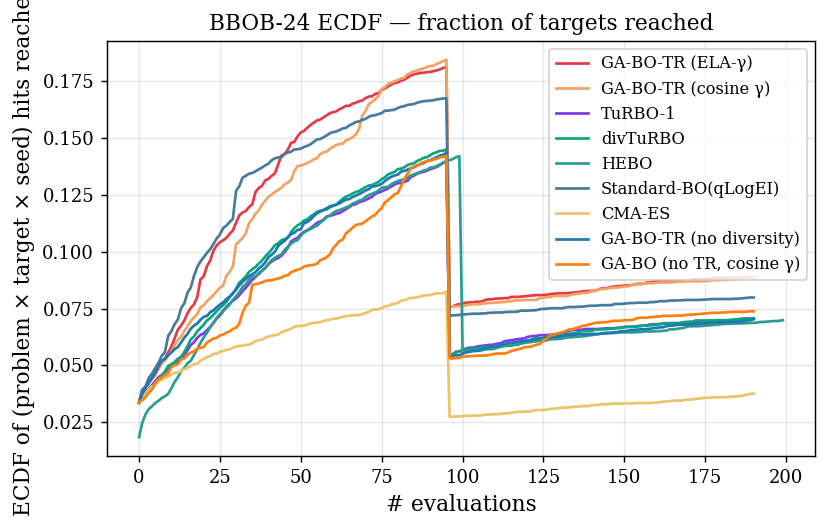

Saved figures_gabotr/bbob_ecdf.pdf


In [22]:
def bbob_ecdf(bbob_results, suite, targets=None, filename="bbob_ecdf.pdf"):
    """ECDF of hitting time across the BBOB sweep."""
    if targets is None:
        targets = np.logspace(2, -6, 31)    # from f*+100 down to f*+1e-6

    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    max_budget = 0
    curves = {}
    for mname, fd in bbob_results.items():
        # count fraction of (problem, target, seed) triples met by iter k
        hits_by_k = None
        total = 0
        for pname, runs in fd.items():
            f_opt = suite[pname].global_optimum
            for r in runs:
                bv = np.array(r.best_values) - f_opt     # length = n_init+n_iter+1
                for tg in targets:
                    met = bv <= tg
                    if hits_by_k is None or len(met) > len(hits_by_k):
                        tmp = np.zeros(len(met))
                        if hits_by_k is not None:
                            tmp[:len(hits_by_k)] = hits_by_k
                        hits_by_k = tmp
                    hits_by_k[:len(met)] += met.astype(int)
                    total += 1
        if hits_by_k is None or total == 0: continue
        curves[mname] = hits_by_k / total
        max_budget = max(max_budget, len(hits_by_k))

    for m, c in curves.items():
        x = np.arange(len(c))
        ax.plot(x, c, label=m, lw=1.5, color=METHOD_COLORS.get(m, None))
    ax.set_xlabel("# evaluations"); ax.set_ylabel("ECDF of (problem × target × seed) hits reached")
    ax.set_title("BBOB-24 ECDF — fraction of targets reached")
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", bbox_inches="tight")
    plt.show()
    print(f"Saved figures_gabotr/{filename}")


bbob_ecdf(BBOB_RESULTS, bbob_suite)


## 7.5 Distributional view: per-method final-regret boxplots

Headline ranks summarise central tendency only.  Q1 reviewers expect a
distributional view — boxplot/violin of final regret across seeds — to
distinguish a *consistent* improvement from one driven by a few lucky
seeds.  We render this for the synthetic suite and (when `LASSO_RESULTS`
is populated) the LassoBench stress test.


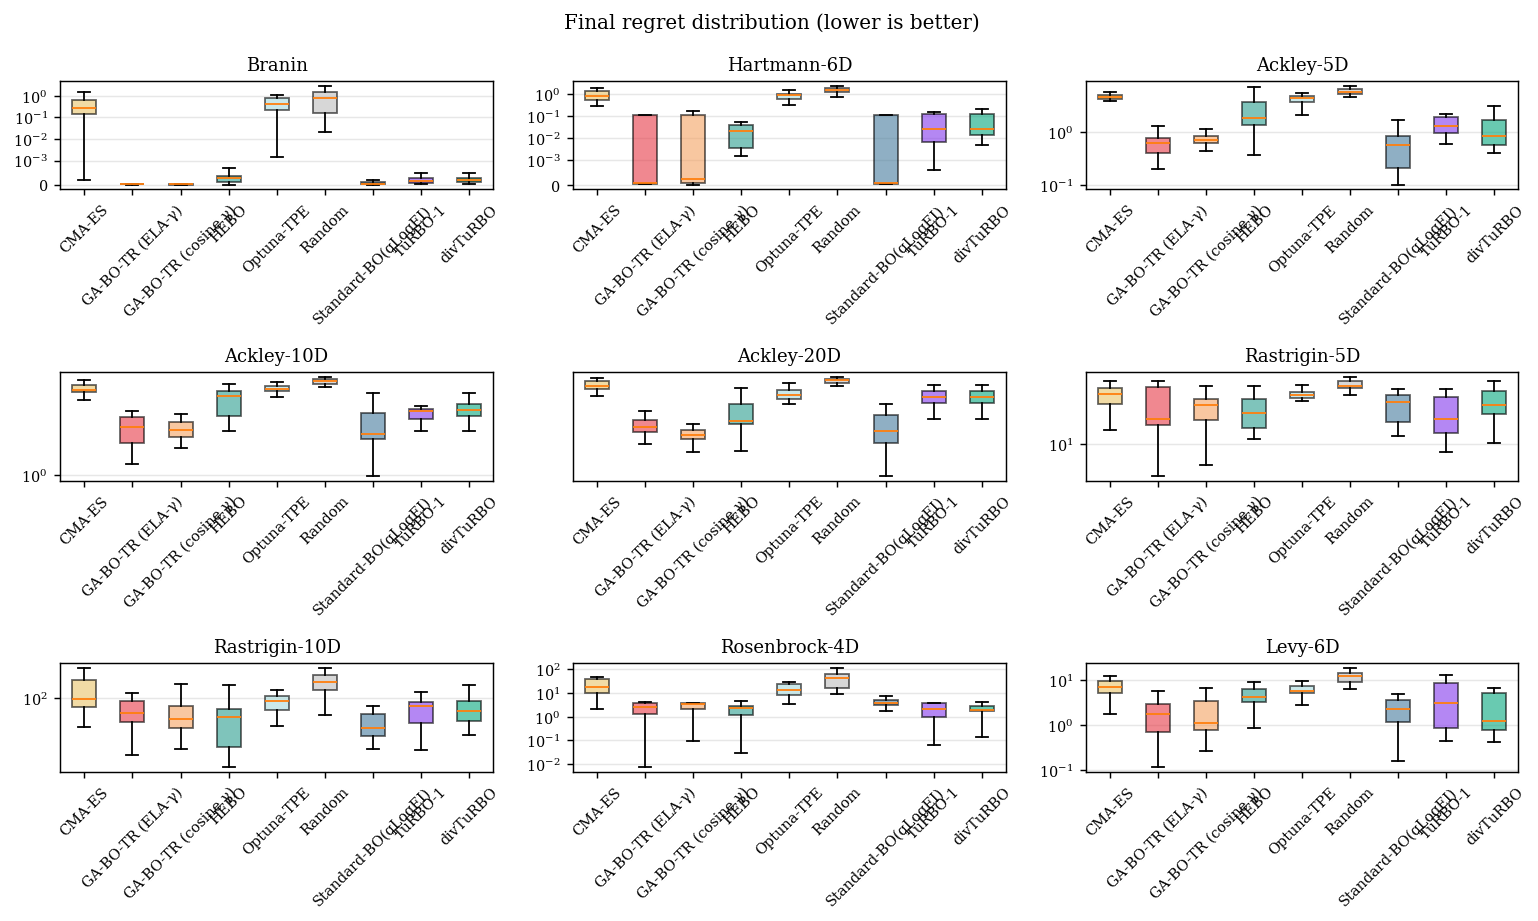

Saved figures_gabotr/regret_boxplot_synth.pdf

=== A12 effect size per function — vs. GA-BO-TR (cosine γ) ===


,Baseline,Function,A12,Magnitude,Direction
0,GA-BO-TR (ELA-γ),Branin,0.342,small,control wins
1,GA-BO-TR (ELA-γ),Hartmann-6D,0.618,negligible,baseline wins
2,GA-BO-TR (ELA-γ),Ackley-5D,0.622,negligible,baseline wins
3,GA-BO-TR (ELA-γ),Ackley-10D,0.467,negligible,control wins
4,GA-BO-TR (ELA-γ),Ackley-20D,0.298,small,control wins
...,...,...,...,...,...
67,Random,Ackley-20D,0.000,large,control wins
68,Random,Rastrigin-5D,0.102,medium,control wins
69,Random,Rastrigin-10D,0.062,medium,control wins
70,Random,Rosenbrock-4D,0.000,large,control wins


In [23]:
def regret_boxplot(results: Dict[str, Dict[str, List[BOResult]]],
                   functions: Dict[str, TestFunction],
                   filename: str = "regret_boxplot.pdf",
                   ncols: int = 3,
                   per_panel_height: float = 2.4):
    rows = []
    for method, by_func in results.items():
        for fname, runs in by_func.items():
            f_opt = functions[fname].global_optimum
            for r in runs:
                rows.append({"Method": method, "Function": fname,
                             "Final regret": r.best_values[-1] - f_opt})
    if not rows:
        print(f"[boxplot {filename}] no data"); return
    df = pd.DataFrame(rows)

    fns = list(functions.keys())
    nrows = (len(fns) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols*4.0, nrows*per_panel_height),
                             squeeze=False)
    axes = axes.flatten()
    methods_ordered = sorted(df["Method"].unique())
    for ax, fname in zip(axes, fns):
        sub = df[df["Function"] == fname]
        data = [sub[sub["Method"] == m]["Final regret"].values
                for m in methods_ordered]
        # Filter out empty arrays so matplotlib doesn't choke on degenerate boxes.
        nonempty = [(d, m) for d, m in zip(data, methods_ordered) if len(d) > 0]
        if not nonempty:
            ax.set_title(f"{fname} (no data)", fontsize=10); ax.axis('off'); continue
        data_ne, labels_ne = zip(*nonempty)
        # `tick_labels=` is the supported keyword in matplotlib 3.9+; older
        # `labels=` still works as alias but emits DeprecationWarning and
        # is removed in 3.11.
        try:
            bp = ax.boxplot(list(data_ne), tick_labels=list(labels_ne),
                            showfliers=False, patch_artist=True)
        except TypeError:
            bp = ax.boxplot(list(data_ne), labels=list(labels_ne),
                            showfliers=False, patch_artist=True)
        methods_ordered_local = list(labels_ne)
        for patch, m in zip(bp["boxes"], methods_ordered_local):
            patch.set_facecolor(METHOD_COLORS.get(m, "#bbbbbb"))
            patch.set_alpha(0.6)
        ax.set_title(fname, fontsize=10)
        ax.tick_params(axis='x', labelrotation=45, labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.set_yscale("symlog", linthresh=1e-3)
        ax.grid(alpha=0.3, axis='y')
    for ax in axes[len(fns):]:
        ax.axis('off')
    fig.suptitle("Final regret distribution (lower is better)", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", bbox_inches="tight")
    plt.show()
    print(f"Saved figures_gabotr/{filename}")


regret_boxplot(SYNTH_RESULTS, SYNTH_FUNCTIONS, filename="regret_boxplot_synth.pdf")
if "LASSO_RESULTS" in globals() and LASSO_RESULTS:
    regret_boxplot(LASSO_RESULTS, LASSO_FUNCTIONS, filename="regret_boxplot_lasso.pdf")

# A12 per-function table (control = GA-BO-TR cosine γ, the headline method).
print("\n=== A12 effect size per function — vs. GA-BO-TR (cosine γ) ===")
display(effect_size_per_function(SYNTH_RESULTS, SYNTH_FUNCTIONS,
                                 control="GA-BO-TR (cosine γ)"))


## 7.6 Compute & resource disclosure

Q1 reviewers will ask: *how long did this take, and how does compute compare
across methods?*  We surface per-method total wall-time and per-run mean,
across all suites that ran in this kernel.  Methods whose mean per-run cost
is high (SAASBO via NUTS, BAxUS in high-d) are flagged for the experiment
section of the paper.


In [24]:
def compute_disclosure(results_by_suite: Dict[str, Dict[str, Dict[str, List[BOResult]]]]
                       ) -> pd.DataFrame:
    rows = []
    for suite_name, results in results_by_suite.items():
        if not results: continue
        for m, by_func in results.items():
            wall = sum(r.wall_time for runs in by_func.values() for r in runs)
            n    = sum(len(runs) for runs in by_func.values())
            if n == 0: continue
            rows.append({"Suite": suite_name, "Method": m,
                         "Runs": n,
                         "Total wall-time (h)": round(wall/3600, 3),
                         "Per-run mean (s)":   round(wall/n, 2)})
    return pd.DataFrame(rows).sort_values(["Suite", "Total wall-time (h)"],
                                          ascending=[True, False]).reset_index(drop=True)


_SUITES_FOR_COMPUTE = {
    "Synthetic":   SYNTH_RESULTS,
    "BBOB":        BBOB_RESULTS  if "BBOB_RESULTS"  in globals() else {},
    "Engineering": ENG_RESULTS_MERGED if "ENG_RESULTS_MERGED" in globals() else {},
    "LassoBench":  LASSO_RESULTS if "LASSO_RESULTS" in globals() else {},
}
COMPUTE_DF = compute_disclosure(_SUITES_FOR_COMPUTE)
display(COMPUTE_DF)
COMPUTE_DF.to_csv(f"{RESULTS_DIR}/compute_disclosure.csv", index=False)
print(f"Saved -> {RESULTS_DIR}/compute_disclosure.csv")


,Suite,Method,Runs,Total wall-time (h),Per-run mean (s)
0,BBOB,HEBO,240,19.954,299.31
1,BBOB,Standard-BO(qLogEI),240,18.512,277.67
2,BBOB,GA-BO-TR (no diversity),240,5.217,78.26
3,BBOB,GA-BO-TR (ELA-γ),240,5.061,75.92
4,BBOB,GA-BO-TR (cosine γ),240,4.979,74.69
5,BBOB,"GA-BO (no TR, cosine γ)",240,4.735,71.02
6,BBOB,divTuRBO,240,2.567,38.50
7,BBOB,TuRBO-1,240,2.554,38.31
8,BBOB,CMA-ES,240,0.001,0.02
9,Engineering,Constrained-BO (cEI),40,34.393,3095.35


Saved -> results_gabotr/compute_disclosure.csv


## 7.7 Reproducibility manifest

Frozen package versions, hardware fingerprint, and random-seed protocol.
Save the stdout of this cell to the paper supplement.


In [25]:
import sys, platform
from importlib.metadata import version
def _v(mod):
    try:
        return __import__(mod).__version__
    except Exception:
        return "n/a"

print("="*70)
print("REPRODUCIBILITY MANIFEST")
print("="*70)
print(f"Python              : {sys.version.split()[0]}")
print(f"Platform            : {platform.platform()}")
print(f"Processor           : {platform.processor() or 'unknown'}")
print(f"CPU count           : {os.cpu_count()}")
print(f"PyTorch             : {_v('torch')}  CUDA={torch.cuda.is_available()}"
      f"{'  device='+torch.cuda.get_device_name(0) if torch.cuda.is_available() else ''}")
print(f"BoTorch             : {_v('botorch')}")
print(f"GPyTorch            : {_v('gpytorch')}")
print(f"NumPy               : {_v('numpy')}")
print(f"SciPy               : {_v('scipy')}")
print(f"pandas              : {_v('pandas')}")
print(f"scikit-learn        : {_v('sklearn')}")
print(f"scikit-posthocs     : {_v('scikit_posthocs')}")
print(f"matplotlib          : {_v('matplotlib')}")
print(f"tqdm                : {_v('tqdm')}")
print(f"ioh                 : {version('ioh')}")
print(f"pflacco             : {version('pflacco')}")
print(f"cma                 : {_v('cma')}")
print(f"optuna              : {_v('optuna')}")
print(f"hebo                : {_v('hebo')}")
print(f"LassoBench          : {version('LassoBench')}")
print(f"joblib              : {_v('joblib')}")
print()
print("Seed protocol")
print("-"*70)
print(f"Synthetic suite     : seeds = list(range({15}))")
print(f"BBOB sweep          : seeds = list(range({N_SEEDS_BBOB}))  (RUN_SCALE='{RUN_SCALE}')")
if "LASSO_RESULTS" in globals() and LASSO_RESULTS:
    n_lasso = len(next(iter(next(iter(LASSO_RESULTS.values())).values())))
    print(f"LassoBench          : seeds = list(range({n_lasso}))")
print(f"Engineering         : seeds = list(range({N_SEEDS_ENG}))   "
      f"({len(ENG_FUNCTIONS)} problems x "
      f"{len(next(iter(ENG_RESULTS.values()))) if ENG_RESULTS else 0} methods "
      f"x {N_SEEDS_ENG} seeds)")
print()
print("Acquisition optimisation")
print("-"*70)
print("  GA inner loop: SBX crossover (eta_c=20) + polynomial mutation (eta_m=20),")
print("                 pop_size_init=80, pop_size_final=20, n_generations=40,")
print("                 elitism=5 best from archive (clipped to TR).")
print("  Trust region : TuRBO success_tolerance=10, length [2^-7, 1.6],")
print("                 anisotropic by GP lengthscales.")
print("  GP fit       : ExactMarginalLogLikelihood, max_attempts=3 in")
print("                 fit_gpytorch_mll; failures logged via _GP_FIT_FAIL_COUNT.")
print()
print("Random-state policy")
print("-"*70)
print("  numpy        : np.random.RandomState(seed) per algorithm instance.")
print("  torch        : torch.manual_seed(int(seed)) per SAASBO call;")
print("                 BoTorch acquisition samplers seeded with `seed=...`.")
print("  joblib       : loky backend with deterministic per-task seed dispatch.")
print()
print(f"GP fit failures     : {_GP_FIT_FAIL_COUNT} (parent process)")
if N_JOBS != 1 or N_JOBS_BBOB != 1:
    print(f"  WARNING: N_JOBS or N_JOBS_BBOB > 1 -- worker process counters")
    print(f"  are NOT aggregated; the figure above under-reports total failures.")
    print(f"  For an exact count, rerun with N_JOBS=1, N_JOBS_BBOB=1.")
print(f"  (Non-zero counts indicate fit_gpytorch_mll fell back to priors;")
print(f"  inspect logs for the offending iterations.)")
print()
print(f"Total compute (all suites in this kernel)")
print("-"*70)
print(f"  total wall-time : {COMPUTE_DF['Total wall-time (h)'].sum():.2f} h")
print(f"  total runs      : {int(COMPUTE_DF['Runs'].sum())}")
print()
print("To reproduce: pin the versions above, set the seed lists above, and")
print(f"choose RUN_SCALE = '{RUN_SCALE}'.  Set N_JOBS / N_JOBS_BBOB to your")
print("workstation's core count for joblib parallel speed-up.")


REPRODUCIBILITY MANIFEST
Python              : 3.11.9
Platform            : Windows-10-10.0.26200-SP0
Processor           : AMD64 Family 25 Model 33 Stepping 0, AuthenticAMD
CPU count           : 16
PyTorch             : 2.3.1+cu121  CUDA=True  device=NVIDIA GeForce RTX 3060 Ti
BoTorch             : 0.17.2
GPyTorch            : 1.15.2
NumPy               : 1.26.0
SciPy               : 1.10.1
pandas              : 2.2.0
scikit-learn        : 1.2.2
scikit-posthocs     : 0.12.0
matplotlib          : 3.10.8
tqdm                : 4.67.3
ioh                 : 0.3.22
pflacco             : 1.2.2
cma                 : 3.2.2
optuna              : 4.8.0
hebo                : 0.3.6
LassoBench          : 0.0.0
joblib              : 1.5.3

Seed protocol
----------------------------------------------------------------------
Synthetic suite     : seeds = list(range(15))
BBOB sweep          : seeds = list(range(5))  (RUN_SCALE='medium')
Engineering         : seeds = list(range(10))   (4 problems x 9 me